# 1 - Creating event dataset for scenario reconstruction from CICIDS2017

## 1.1 - Creating machine learning datasets

### 1.1.1 - Validate files

In [1]:
import os
print(os.getcwd())
for root, dirs, files in os.walk('./data'):
        print(root+":")
        if dirs:
            print('\n'.join(dirs))
        if files:
            print('\n'.join(files))

/home/users/davide.zhang/Work_in_progress
./data:
dollar_char_train
dollar_char_test
.ipynb_checkpoints
normal_train
normal_test
final datasets
result logs
ML_train.csv
ML_test.csv
train.csv
test.csv
normal_train.csv
normal_test.csv
./data/dollar_char_train:
.ipynb_checkpoints
dollar_char_train.npz
dollar_char_train.pkl
dollar_char_train.csv
dollar_char_train_labeled.csv
./data/dollar_char_train/.ipynb_checkpoints:
dollar_char_train_labeled-checkpoint.csv
./data/dollar_char_test:
.ipynb_checkpoints
dollar_char_test.pkl
dollar_char_test.npz
dollar_char_test.csv
dollar_char_test_labeled.csv
./data/dollar_char_test/.ipynb_checkpoints:
dollar_char_test_labeled-checkpoint.csv
dollar_char_test-checkpoint.csv
./data/.ipynb_checkpoints:
ML_train-checkpoint.csv
train-checkpoint.csv
normal_train-checkpoint.csv
test-checkpoint.csv
normal_test-checkpoint.csv
./data/normal_train:
.ipynb_checkpoints
normal_2_3_4.csv
./data/normal_train/.ipynb_checkpoints:
normal_2_3_4-checkpoint.csv
./data/normal_te

### 1.1.2 - Dataset loading

In [2]:
import pandas as pd
import numpy as np
df_train=pd.read_csv("./data/train.csv")
df_test=pd.read_csv("./data/test.csv")

/tmp/ipykernel_3082752/1085510059.py:3: DtypeWarning: Columns (0: client_fingerprint, 1: server_fingerprint) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train=pd.read_csv("./data/train.csv")
/tmp/ipykernel_3082752/1085510059.py:4: DtypeWarning: Columns (0: client_fingerprint, 1: server_fingerprint) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test=pd.read_csv("./data/test.csv")


In [3]:
df_test["index"] = np.arange(len(df_test))

### 1.1.3 - Dataset cleaning

In [4]:
df_train.columns = df_train.columns.str.strip()
initial_columns=df_train.columns
for column in initial_columns:
    if any([keyword in column for keyword in ["id", "ip", "mac", "oui", "duration", "seen", "protocol", "Unnamed", "fingerprint", "timestamp", "phase", "step"]]):
        df_train=df_train.drop(column, axis=1)
        df_test=df_test.drop(column, axis=1)

In [5]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 413309 entries, 0 to 413308
Data columns (total 45 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   src_port                   413309 non-null  int64  
 1   dst_port                   413309 non-null  int64  
 2   src2dst_packets            413309 non-null  int64  
 3   src2dst_bytes              413309 non-null  int64  
 4   dst2src_packets            413309 non-null  int64  
 5   dst2src_bytes              413309 non-null  int64  
 6   src2dst_min_ps             208220 non-null  float64
 7   src2dst_mean_ps            413309 non-null  float64
 8   src2dst_stddev_ps          413309 non-null  float64
 9   src2dst_max_ps             208220 non-null  float64
 10  dst2src_min_ps             208220 non-null  float64
 11  dst2src_mean_ps            413309 non-null  float64
 12  dst2src_stddev_ps          413309 non-null  float64
 13  dst2src_max_ps             208220 non-nu

In [6]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 296132 entries, 0 to 296131
Data columns (total 46 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   src_port                   296132 non-null  int64  
 1   dst_port                   296132 non-null  int64  
 2   src2dst_packets            296132 non-null  int64  
 3   src2dst_bytes              296132 non-null  int64  
 4   dst2src_packets            296132 non-null  int64  
 5   dst2src_bytes              296132 non-null  int64  
 6   src2dst_min_ps             121482 non-null  float64
 7   src2dst_mean_ps            296132 non-null  float64
 8   src2dst_stddev_ps          296132 non-null  float64
 9   src2dst_max_ps             121482 non-null  float64
 10  dst2src_min_ps             121482 non-null  float64
 11  dst2src_mean_ps            296132 non-null  float64
 12  dst2src_stddev_ps          296132 non-null  float64
 13  dst2src_max_ps             121482 non-nu

In [7]:
import numpy as np
df_train = df_train.dropna(thresh=2, axis=1)
df_train = df_train.dropna(thresh=2, axis=0)
df_test = df_test.dropna(thresh=2, axis=1)
df_test = df_test.dropna(thresh=2, axis=0)

In [8]:
num_cols = df_train.select_dtypes(include="number").columns
df_train[num_cols] = df_train[num_cols].replace([np.inf, -np.inf, np.nan], -1)

str_cols = df_train.select_dtypes(exclude="number").columns
df_train[str_cols] = df_train[str_cols].fillna(" ")

In [9]:
num_cols = df_test.select_dtypes(include="number").columns
df_test[num_cols] = df_test[num_cols].replace([np.inf, -np.inf, np.nan], -1)

str_cols = df_test.select_dtypes(exclude="number").columns
df_test[str_cols] = df_test[str_cols].fillna(" ")

In [10]:
print(df_train.isna().sum().sum())

0


In [11]:
print(df_test.isna().sum().sum())

0


In [12]:
THRESHOLD = 0.99

In [13]:
low_var_cols = [
    col for col in df_train.columns
    if df_train[col].value_counts(normalize=True, dropna=False).iloc[0] >= THRESHOLD
]

df_train = df_train.drop(columns=low_var_cols)
df_test = df_test.drop(columns=low_var_cols)

In [14]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 413309 entries, 0 to 413308
Data columns (total 42 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   src_port                   413309 non-null  int64  
 1   dst_port                   413309 non-null  int64  
 2   src2dst_packets            413309 non-null  int64  
 3   src2dst_bytes              413309 non-null  int64  
 4   dst2src_packets            413309 non-null  int64  
 5   dst2src_bytes              413309 non-null  int64  
 6   src2dst_min_ps             413309 non-null  float64
 7   src2dst_mean_ps            413309 non-null  float64
 8   src2dst_stddev_ps          413309 non-null  float64
 9   src2dst_max_ps             413309 non-null  float64
 10  dst2src_min_ps             413309 non-null  float64
 11  dst2src_mean_ps            413309 non-null  float64
 12  dst2src_stddev_ps          413309 non-null  float64
 13  dst2src_max_ps             413309 non-nu

In [15]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 296132 entries, 0 to 296131
Data columns (total 43 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   src_port                   296132 non-null  int64  
 1   dst_port                   296132 non-null  int64  
 2   src2dst_packets            296132 non-null  int64  
 3   src2dst_bytes              296132 non-null  int64  
 4   dst2src_packets            296132 non-null  int64  
 5   dst2src_bytes              296132 non-null  int64  
 6   src2dst_min_ps             296132 non-null  float64
 7   src2dst_mean_ps            296132 non-null  float64
 8   src2dst_stddev_ps          296132 non-null  float64
 9   src2dst_max_ps             296132 non-null  float64
 10  dst2src_min_ps             296132 non-null  float64
 11  dst2src_mean_ps            296132 non-null  float64
 12  dst2src_stddev_ps          296132 non-null  float64
 13  dst2src_max_ps             296132 non-nu

In [16]:
df_test=df_test.drop([col for col in df_test.columns if col not in df_train.columns and col!="index"], axis=1)
df_train=df_train.drop([col for col in df_train.columns if col not in df_test.columns], axis=1)

In [17]:
df_train["label"].value_counts()

label
normal                   221500
nmap_10_T5               189004
nmap_mqtt                   932
nmap_banner                 918
brute_force_malformed       458
nmap_sub                    302
dollar_char                 188
scp_inst                      7
Name: count, dtype: int64

In [18]:
df_test["label"].value_counts()

label
normal                   188000
nmap_10_T5               105000
nmap_banner                1304
nmap_mqtt                  1300
brute_force_malformed       448
dollar_char                  70
scp_inst                      9
mqtt_cat                      1
Name: count, dtype: int64

In [19]:
df_test=df_test[df_test["label"].isin(df_train["label"].unique())]
df_train=df_train[df_train["label"].isin(df_test["label"].unique())]

In [20]:
df_train["label"].value_counts()

label
normal                   221500
nmap_10_T5               189004
nmap_mqtt                   932
nmap_banner                 918
brute_force_malformed       458
dollar_char                 188
scp_inst                      7
Name: count, dtype: int64

In [21]:
df_test["label"].value_counts()

label
normal                   188000
nmap_10_T5               105000
nmap_banner                1304
nmap_mqtt                  1300
brute_force_malformed       448
dollar_char                  70
scp_inst                      9
Name: count, dtype: int64

### 1.1.7 - Saving train-set and test-set

In [22]:
df_train.to_csv("./data/ML_train.csv", index=False)
df_test.to_csv("./data/ML_test.csv", index=False)

## 1.2 - Computing anomaly score

### 1.2.1 - Loading the datasets

In [23]:
import numpy as np
import pandas as pd
df_train=pd.read_csv("./data/ML_train.csv")
df_test=pd.read_csv("./data/ML_test.csv")
ind_test=df_test["index"]

### 1.2.2 - Categorical encoding for anomaly detection

In [24]:
attack_labels=["nmap_10_T5", "nmap_banner", "nmap_mqtt", "brute_force_malformed", "dollar_char", "scp_inst"]

In [25]:
def label_encode(dataframe, tags):
    dataframe=dataframe.copy()
    dataframe['label'] = dataframe['label'].isin(tags).astype(int)
    obj_cols=[col for col in dataframe.columns if pd.api.types.is_object_dtype(dataframe[col].dtype) or pd.api.types.is_string_dtype(dataframe[col].dtype)]
    categories = {}
    for obj_col in obj_cols:
        categories[obj_col] = pd.Index(dataframe[obj_col].unique())
        dataframe[obj_col] = pd.Categorical(dataframe[obj_col], categories=categories[obj_col])
        dataframe[obj_col] = dataframe[obj_col].cat.codes
    return dataframe, categories

In [26]:
def label_encode_categories(dataframe, tags, categories):
    dataframe=dataframe.copy()
    dataframe['label'] = dataframe['label'].isin(tags).astype(int)
    obj_cols=[col for col in dataframe.columns if pd.api.types.is_object_dtype(dataframe[col].dtype) or pd.api.types.is_string_dtype(dataframe[col].dtype)]
    for obj_col in obj_cols:
        dataframe[obj_col] = pd.Categorical(dataframe[obj_col], categories=categories[obj_col])
        dataframe[obj_col] = dataframe[obj_col].cat.codes
    return dataframe

In [27]:
print(df_train.isna().sum().sum())

0


In [28]:
print(df_test.isna().sum().sum())

0


In [29]:
df_train_encoded, categories=label_encode(df_train, attack_labels)
df_test_encoded=label_encode_categories(df_test, attack_labels, categories)

In [30]:
df_train_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 413007 entries, 0 to 413006
Data columns (total 42 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   src_port                   413007 non-null  int64  
 1   dst_port                   413007 non-null  int64  
 2   src2dst_packets            413007 non-null  int64  
 3   src2dst_bytes              413007 non-null  int64  
 4   dst2src_packets            413007 non-null  int64  
 5   dst2src_bytes              413007 non-null  int64  
 6   src2dst_min_ps             413007 non-null  float64
 7   src2dst_mean_ps            413007 non-null  float64
 8   src2dst_stddev_ps          413007 non-null  float64
 9   src2dst_max_ps             413007 non-null  float64
 10  dst2src_min_ps             413007 non-null  float64
 11  dst2src_mean_ps            413007 non-null  float64
 12  dst2src_stddev_ps          413007 non-null  float64
 13  dst2src_max_ps             413007 non-nu

In [31]:
df_test_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 296131 entries, 0 to 296130
Data columns (total 43 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   src_port                   296131 non-null  int64  
 1   dst_port                   296131 non-null  int64  
 2   src2dst_packets            296131 non-null  int64  
 3   src2dst_bytes              296131 non-null  int64  
 4   dst2src_packets            296131 non-null  int64  
 5   dst2src_bytes              296131 non-null  int64  
 6   src2dst_min_ps             296131 non-null  float64
 7   src2dst_mean_ps            296131 non-null  float64
 8   src2dst_stddev_ps          296131 non-null  float64
 9   src2dst_max_ps             296131 non-null  float64
 10  dst2src_min_ps             296131 non-null  float64
 11  dst2src_mean_ps            296131 non-null  float64
 12  dst2src_stddev_ps          296131 non-null  float64
 13  dst2src_max_ps             296131 non-nu

In [32]:
print(df_train_encoded.isna().sum().sum())

0


In [33]:
print(df_test_encoded.isna().sum().sum())

0


### 1.2.3 - Feature label separation

In [34]:
y_train, X_train= df_train_encoded["label"], df_train_encoded.drop("label", axis=1)
y_test, X_test= df_test_encoded["label"], df_test_encoded.drop(["label", "index"], axis=1)
X_train.info()
X_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 413007 entries, 0 to 413006
Data columns (total 41 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   src_port                   413007 non-null  int64  
 1   dst_port                   413007 non-null  int64  
 2   src2dst_packets            413007 non-null  int64  
 3   src2dst_bytes              413007 non-null  int64  
 4   dst2src_packets            413007 non-null  int64  
 5   dst2src_bytes              413007 non-null  int64  
 6   src2dst_min_ps             413007 non-null  float64
 7   src2dst_mean_ps            413007 non-null  float64
 8   src2dst_stddev_ps          413007 non-null  float64
 9   src2dst_max_ps             413007 non-null  float64
 10  dst2src_min_ps             413007 non-null  float64
 11  dst2src_mean_ps            413007 non-null  float64
 12  dst2src_stddev_ps          413007 non-null  float64
 13  dst2src_max_ps             413007 non-nu

### 1.2.4 - Standardization

In [35]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

### 1.2.5 - Feature Importance

In [36]:
from sklearn.ensemble import RandomForestRegressor
regressor=RandomForestRegressor(random_state=42, n_jobs=-1)
regressor.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [37]:
for i in range(X_train.shape[1]):
    print(f"{df_train_encoded.columns[i]}: {np.round(regressor.feature_importances_[i],3)}")

src_port: 0.0
dst_port: 0.0
src2dst_packets: 0.0
src2dst_bytes: 0.0
dst2src_packets: 0.0
dst2src_bytes: 0.0
src2dst_min_ps: 0.0
src2dst_mean_ps: 0.0
src2dst_stddev_ps: 0.0
src2dst_max_ps: 0.0
dst2src_min_ps: 0.0
dst2src_mean_ps: 0.993
dst2src_stddev_ps: 0.004
dst2src_max_ps: 0.0
src2dst_min_piat_ms: 0.0
src2dst_mean_piat_ms: 0.0
src2dst_stddev_piat_ms: 0.0
src2dst_max_piat_ms: 0.001
dst2src_min_piat_ms: 0.0
dst2src_mean_piat_ms: 0.0
dst2src_stddev_piat_ms: 0.0
dst2src_max_piat_ms: 0.001
src2dst_syn_packets: 0.0
src2dst_cwr_packets: 0.0
src2dst_ece_packets: 0.0
src2dst_urg_packets: 0.0
src2dst_ack_packets: 0.0
src2dst_psh_packets: 0.0
src2dst_rst_packets: 0.0
src2dst_fin_packets: 0.0
dst2src_syn_packets: 0.0
dst2src_cwr_packets: 0.0
dst2src_ece_packets: 0.0
dst2src_urg_packets: 0.0
dst2src_ack_packets: 0.0
dst2src_psh_packets: 0.0
dst2src_rst_packets: 0.0
dst2src_fin_packets: 0.0
application_name: 0.0
application_category_name: 0.0
application_is_guessed: 0.0


### 1.2.7 - Computing contamination

In [38]:
print("contamination: ")
print(y_train.value_counts().get(1)/len(y_train))

contamination: 
0.46368947741805827


### 1.2.8 - Train anomaly detectors

In [39]:
from pyod.models.iforest import IForest
iforest=IForest(contamination=0.46, n_estimators=500,  n_jobs=10, random_state=42)
iforest.fit(X_train)

,n_estimators,500
,max_samples,'auto'
,contamination,0.46
,max_features,1.0
,bootstrap,False
,n_jobs,10
,behaviour,'old'
,random_state,42
,verbose,0


In [40]:
from pyod.models.hbos import HBOS
hbos=HBOS(n_bins=500, contamination=0.46)
hbos.fit(X_train)

,n_bins,500
,alpha,0.1
,tol,0.5
,contamination,0.46


In [41]:
from pyod.models.sampling import Sampling
sampling=Sampling(contamination=0.46, subset_size=200, random_state=42)
sampling.fit(X_train)

,contamination,0.46
,subset_size,200
,metric,'minkowski'
,metric_params,None
,random_state,RandomState(M...0x7F1FF07B3E40


In [42]:
from sklearn.naive_bayes import GaussianNB
naive_bayes=GaussianNB()
naive_bayes.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [43]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
qda = QuadraticDiscriminantAnalysis(reg_param=1.0)
qda.fit(X_train, y_train)

,"solver solver: {'svd', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter. Enabling shrinkage is expected to improve the model when some classes have a relatively small number of training data points compared to the number of features by mitigating overfitting during the covariance estimation step.This should be left to `None` if `covariance_estimator` is used.Note that shrinkage works only with 'eigen' solver.",None
,"priors priors: array-like of shape (n_classes,), default=NoneClass priors. By default, the class proportions are inferred from thetraining data.",None
,"reg_param reg_param: float, default=0.0Regularizes the per-class covariance estimates by transforming S2 as``S2 = (1 - reg_param) * S2 + reg_param * np.eye(n_features)``,where S2 corresponds to the `scaling_` attribute of a given class.",1.0
,"store_covariance store_covariance: bool, default=FalseIf True, the class covariance matrices are explicitly computed andstored in the `self.covariance_` attribute... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for the covariance matrix to be considered rankdeficient after applying some regularization (see `reg_param`) to each`Sk` where `Sk` represents covariance matrix for k-th class. Thisparameter does not affect the predictions. It controls when a warningis raised if the covariance matrix is not full rank... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimate the covariancematrices instead of relying on the empirical covariance estimator(with potential shrinkage). The object should have a fit method anda ``covariance_`` attribute like the estimators in:mod:`sklearn.covariance`. If None the shrinkage parameter drives theestimate.This should be left to `None` if `shrinkage` is used.Note that `covariance_estimator` works only with the 'eigen' solver.",None


In [44]:
from sklearn.linear_model import LogisticRegression
logistic_regression=LogisticRegression(max_iter=500, random_state=42)
logistic_regression.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [45]:
from xgboost import XGBClassifier
xgb=XGBClassifier(n_estimators=50, random_state=42)
xgb.fit(X_train,y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

### 1.2.9 - Test anomaly detection function definition

In [46]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
def evaluate_metrics(predictor, name):
    y_pred=predictor.predict(X_test)
    acc=accuracy_score(y_test, y_pred)
    print(f"{name} test accuracy: {acc:.3f}")
    rec=recall_score(y_test, y_pred)
    print(f"{name} test recall: {rec:.3f}")
    prec=precision_score(y_test, y_pred)
    print(f"{name} test precision: {prec:.3f}")

### 1.2.10 - ROC and Precision-Recall Functions definition

In [47]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

def show_roc(predictor, name):
    y_prob = predictor.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)

    fig, ax = plt.subplots(figsize=(6, 5))

    RocCurveDisplay(
        fpr=fpr,
        tpr=tpr,
        roc_auc=roc_auc,
        estimator_name=name
    ).plot(ax=ax)

    ax.set_title(name)
    ax.grid(True)

    fig.suptitle(f"ROC Curve ({name})", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    fig.savefig(f"roc_{name}.png", dpi=300, bbox_inches="tight")
    plt.show()

    return y_prob

In [48]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    PrecisionRecallDisplay,
)
import matplotlib.pyplot as plt

def show_prc(predictor, name):
    y_prob = predictor.predict_proba(X_test)[:, 1]

    pre, rec, _ = precision_recall_curve(y_test, y_prob)
    avg_pre = average_precision_score(y_test, y_prob)

    fig, ax = plt.subplots(figsize=(6, 5))

    PrecisionRecallDisplay(
        precision=pre,
        recall=rec,
        average_precision=avg_pre,
        estimator_name=name
    ).plot(ax=ax)

    ax.set_title(name)
    ax.grid(True)

    fig.suptitle(f"Precision-Recall Curve ({name})", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    fig.savefig(f"prc_{name}.png", dpi=300, bbox_inches="tight")
    plt.show()

    return y_prob

In [49]:
from sklearn.metrics import precision_recall_curve
def compute_thresh(predictor, recall):
    y_prob=predictor.predict_proba(X_test)[:,1]
    pre, rec, thresh = precision_recall_curve(y_test, y_prob)
    threshold = thresh[np.where(rec >= recall)[0][-1]]
    print(f"Computed threshold: {threshold}")

### 1.2.11 - Test anomaly detectors

In [50]:
evaluate_metrics(iforest, "IForest")

IForest test accuracy: 0.150
IForest test recall: 0.116
IForest test precision: 0.074


/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


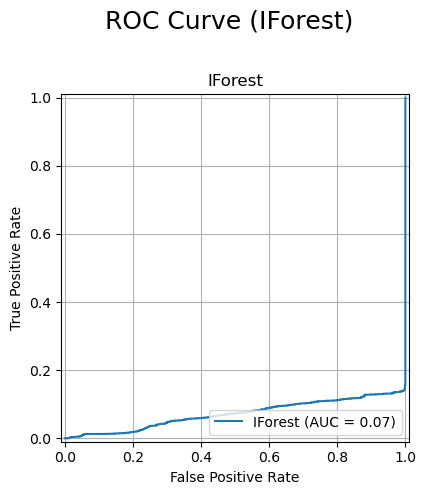

array([0.63276727, 0.65438629, 0.58630123, ..., 0.74089766, 0.74509587,
       0.72505062], shape=(296131,))

In [51]:
show_roc(iforest, "IForest")

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(


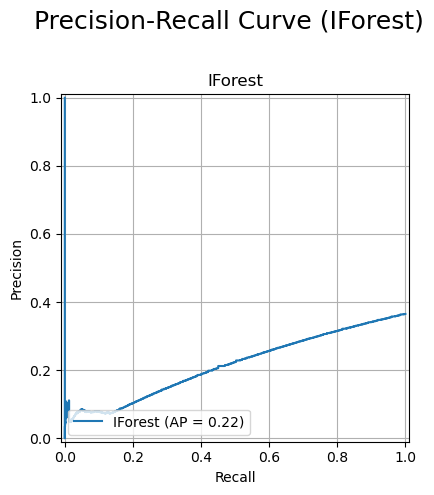

array([0.63276727, 0.65438629, 0.58630123, ..., 0.74089766, 0.74509587,
       0.72505062], shape=(296131,))

In [52]:
show_prc(iforest, "IForest")

In [53]:
evaluate_metrics(hbos, "HBOS")

HBOS test accuracy: 0.042
HBOS test recall: 0.005
HBOS test precision: 0.003


/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


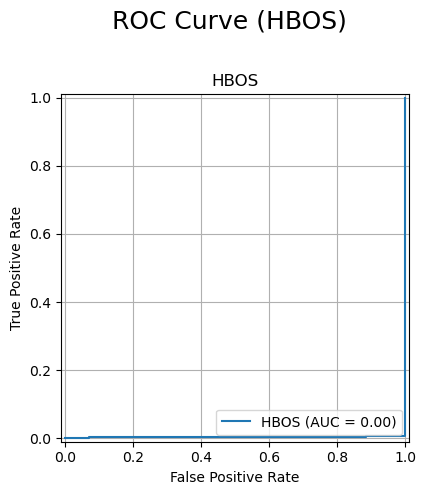

array([0.68508388, 0.65190045, 0.39066166, ..., 0.682884  , 0.77980749,
       0.6720177 ], shape=(296131,))

In [54]:
show_roc(hbos, "HBOS")

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(


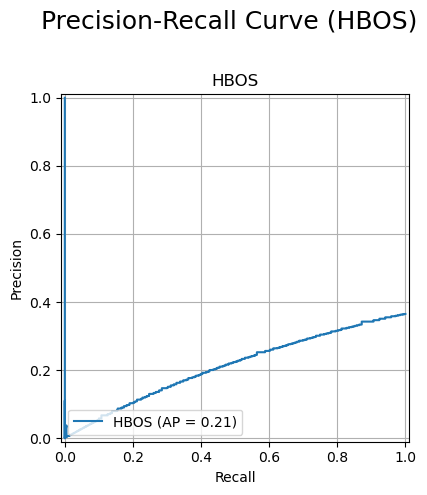

array([0.68508388, 0.65190045, 0.39066166, ..., 0.682884  , 0.77980749,
       0.6720177 ], shape=(296131,))

In [55]:
show_prc(hbos, "HBOS")

In [56]:
evaluate_metrics(sampling, "Sampling")

Sampling test accuracy: 0.091
Sampling test recall: 0.150
Sampling test precision: 0.084


/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


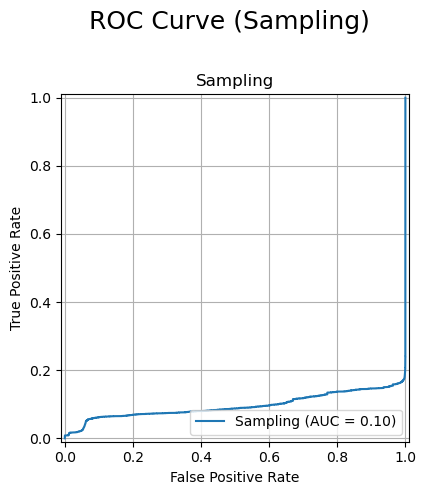

array([0.06062823, 0.05052829, 0.05497608, ..., 0.07541107, 0.07237575,
       0.06803267], shape=(296131,))

In [57]:
show_roc(sampling, "Sampling")

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(


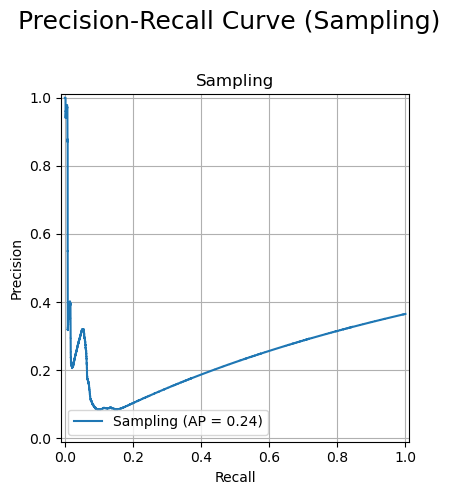

array([0.06062823, 0.05052829, 0.05497608, ..., 0.07541107, 0.07237575,
       0.06803267], shape=(296131,))

In [58]:
show_prc(sampling, "Sampling")

In [59]:
evaluate_metrics(naive_bayes, "GaussianNB")

GaussianNB test accuracy: 0.998
GaussianNB test recall: 0.994
GaussianNB test precision: 1.000


/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


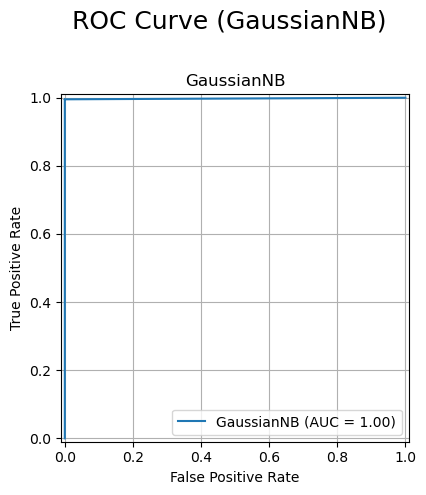

array([3.72128764e-110, 8.82976786e-119, 1.88555887e-116, ...,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000], shape=(296131,))

In [60]:
show_roc(naive_bayes, "GaussianNB")

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(


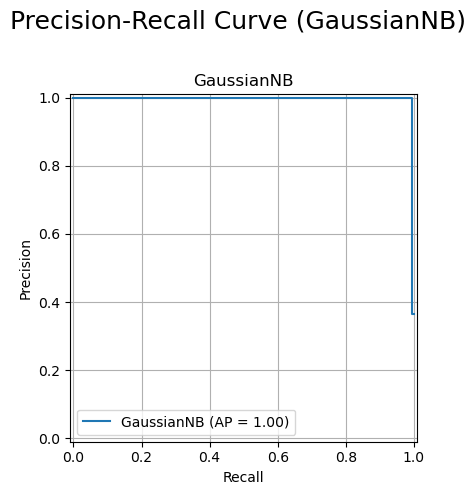

array([3.72128764e-110, 8.82976786e-119, 1.88555887e-116, ...,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000], shape=(296131,))

In [61]:
show_prc(naive_bayes, "GaussianNB")

In [62]:
evaluate_metrics(qda, "QuadraticDiscriminantAnalysis")

QuadraticDiscriminantAnalysis test accuracy: 0.959
QuadraticDiscriminantAnalysis test recall: 1.000
QuadraticDiscriminantAnalysis test precision: 0.899


/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


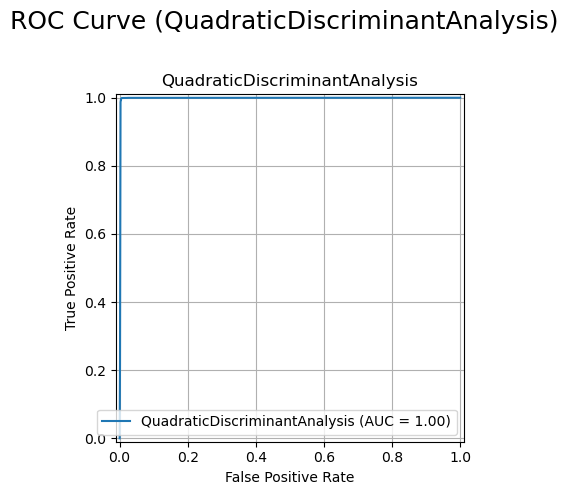

array([1., 1., 1., ..., 1., 1., 1.], shape=(296131,))

In [63]:
show_roc(qda, "QuadraticDiscriminantAnalysis")

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(


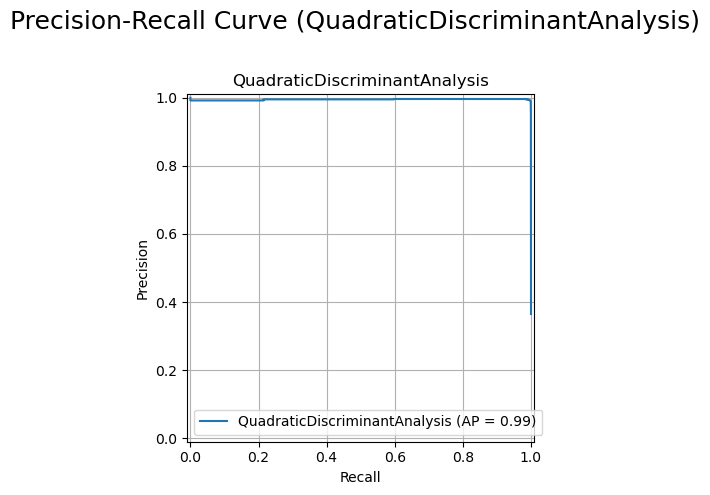

array([1., 1., 1., ..., 1., 1., 1.], shape=(296131,))

In [64]:
show_prc(qda, "QuadraticDiscriminantAnalysis")

In [65]:
evaluate_metrics(logistic_regression, "LogisticRegression")

LogisticRegression test accuracy: 1.000
LogisticRegression test recall: 1.000
LogisticRegression test precision: 1.000


/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


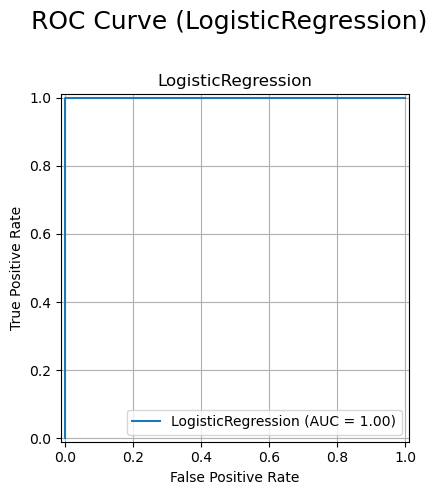

array([0.87924727, 0.67187937, 0.74652325, ..., 0.75736088, 0.66796305,
       0.57736934], shape=(296131,))

In [66]:
show_roc(logistic_regression, "LogisticRegression")

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(


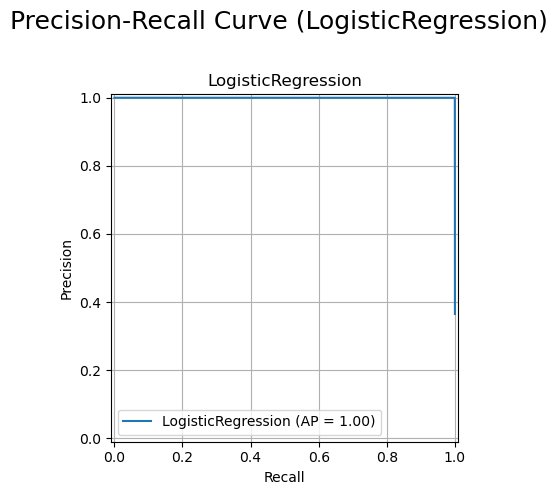

array([0.87924727, 0.67187937, 0.74652325, ..., 0.75736088, 0.66796305,
       0.57736934], shape=(296131,))

In [67]:
show_prc(logistic_regression, "LogisticRegression")

In [68]:
evaluate_metrics(xgb, "XGBClassifier")

XGBClassifier test accuracy: 1.000
XGBClassifier test recall: 1.000
XGBClassifier test precision: 1.000


/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


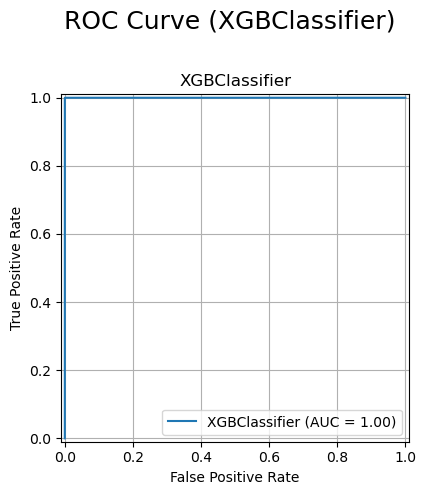

array([0.02015026, 0.0122799 , 0.9999492 , ..., 0.99972504, 0.9995921 ,
       0.9995921 ], shape=(296131,), dtype=float32)

In [69]:
show_roc(xgb, "XGBClassifier")

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(


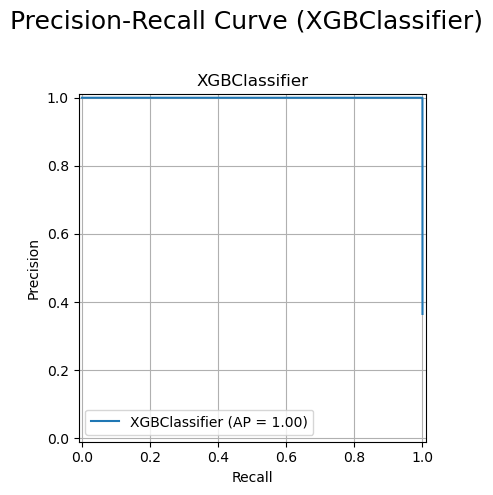

array([0.02015026, 0.0122799 , 0.9999492 , ..., 0.99972504, 0.9995921 ,
       0.9995921 ], shape=(296131,), dtype=float32)

In [70]:
show_prc(xgb, "XGBClassifier")

### 1.2.12 - Computing target threshold

In [71]:
print("Isolation Forest")
compute_thresh(iforest, 0.8)

Isolation Forest
Computed threshold: 0.005504753505551574


In [72]:
print("Logistic Regression")
compute_thresh(logistic_regression, 0.8)

Logistic Regression
Computed threshold: 0.9999996609030759


In [73]:
print("XGBoost")
compute_thresh(xgb, 0.8)

XGBoost
Computed threshold: 0.9999977350234985


In [74]:
print("Quadratic Discriminant Analysis")
compute_thresh(qda, 0.8)

Quadratic Discriminant Analysis
Computed threshold: 0.9999999999999996


In [75]:
print("Naive Bayes")
compute_thresh(naive_bayes, 0.8)

Naive Bayes
Computed threshold: 1.0


In [76]:
print("Sampling")
compute_thresh(sampling, 0.8)

Sampling
Computed threshold: 0.0013600784894450832


In [77]:
print("HBOS")
compute_thresh(hbos, 0.8)

HBOS
Computed threshold: 0.06213831459169605


### 1.2.13 - Computing anomaly score 

In [78]:
anomaly_score_dict={}
anomaly_score_dict["logistic_regression"]=logistic_regression.predict_proba(X_test)[:,1]
anomaly_score_dict["xgb"]=xgb.predict_proba(X_test)[:,1]
anomaly_score_dict["qda"]=qda.predict_proba(X_test)[:,1]
anomaly_score_dict["naive_bayes"]=naive_bayes.predict_proba(X_test)[:,1]
anomaly_score_dict["sampling"]=sampling.predict_proba(X_test)[:,1]
anomaly_score_dict["hbos"]=hbos.predict_proba(X_test)[:,1]
anomaly_score_dict["iforest"]=iforest.predict_proba(X_test)[:,1]
anomaly_score_dict["perfect"]=y_test

In [79]:
for key, df in anomaly_score_dict.items():
    print(key+ f": {df.size}")

logistic_regression: 296131
xgb: 296131
qda: 296131
naive_bayes: 296131
sampling: 296131
hbos: 296131
iforest: 296131
perfect: 296131


## 1.3 - Computing attack type score

### 1.3.1 - Loading the datasets

In [80]:
import numpy as np
import pandas as pd
df_train=pd.read_csv("./data/ML_train.csv")
df_test=pd.read_csv("./data/ML_test.csv")
ind_test=df_test["index"]

### 1.3.2 - Categorical encoding for type mapping

In [81]:
df_dict_train={}
df_dict_test={}
attack_types=[label for label, value in df_train['label'].value_counts().items() if label!='normal']
print(attack_types)
for label in attack_types:
    df_dict_train[label], categories=label_encode(df_train, [label])
    df_dict_test[label]=label_encode_categories(df_test, [label], categories)

['nmap_10_T5', 'nmap_mqtt', 'nmap_banner', 'brute_force_malformed', 'dollar_char', 'scp_inst']


In [82]:
for label in attack_types:
    print(label)
    print("train set")
    print(df_dict_train[label]["label"].value_counts())
    print("test set")
    print(df_dict_test[label]["label"].value_counts())

nmap_10_T5
train set
label
0    224003
1    189004
Name: count, dtype: int64
test set
label
0    191131
1    105000
Name: count, dtype: int64
nmap_mqtt
train set
label
0    412075
1       932
Name: count, dtype: int64
test set
label
0    294831
1      1300
Name: count, dtype: int64
nmap_banner
train set
label
0    412089
1       918
Name: count, dtype: int64
test set
label
0    294827
1      1304
Name: count, dtype: int64
brute_force_malformed
train set
label
0    412549
1       458
Name: count, dtype: int64
test set
label
0    295683
1       448
Name: count, dtype: int64
dollar_char
train set
label
0    412819
1       188
Name: count, dtype: int64
test set
label
0    296061
1        70
Name: count, dtype: int64
scp_inst
train set
label
0    413000
1         7
Name: count, dtype: int64
test set
label
0    296122
1         9
Name: count, dtype: int64


### 1.3.4 - Feature label separation

In [83]:
y_train_dict={}
X_train_dict={}
y_test_dict={}
X_test_dict={}

for label in attack_types:
    y_train_dict[label], X_train_dict[label]= df_dict_train[label]["label"], df_dict_train[label].drop("label", axis=1)
    y_test_dict[label], X_test_dict[label]= df_dict_test[label]["label"], df_dict_test[label].drop(["label", "index"], axis=1)
    X_train_dict[label].info()
    X_test_dict[label].info()

<class 'pandas.DataFrame'>
RangeIndex: 413007 entries, 0 to 413006
Data columns (total 41 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   src_port                   413007 non-null  int64  
 1   dst_port                   413007 non-null  int64  
 2   src2dst_packets            413007 non-null  int64  
 3   src2dst_bytes              413007 non-null  int64  
 4   dst2src_packets            413007 non-null  int64  
 5   dst2src_bytes              413007 non-null  int64  
 6   src2dst_min_ps             413007 non-null  float64
 7   src2dst_mean_ps            413007 non-null  float64
 8   src2dst_stddev_ps          413007 non-null  float64
 9   src2dst_max_ps             413007 non-null  float64
 10  dst2src_min_ps             413007 non-null  float64
 11  dst2src_mean_ps            413007 non-null  float64
 12  dst2src_stddev_ps          413007 non-null  float64
 13  dst2src_max_ps             413007 non-nu

### 1.3.5 - Standardization

In [84]:
from sklearn.preprocessing import StandardScaler
for label in attack_types:
    scaler = StandardScaler()
    scaler.fit(X_train_dict[label])
    X_train_dict[label] = scaler.transform(X_train_dict[label])
    X_test_dict[label] = scaler.transform(X_test_dict[label])

### 1.3.5 - Train type mappers

In [85]:
from xgboost import XGBClassifier
xgb_dict={}
for label in attack_types:
    xgboost=XGBClassifier(n_estimators=50, random_state=42)
    xgboost.fit(X_train_dict[label], y_train_dict[label])
    xgb_dict[label]=xgboost

In [86]:
from sklearn.naive_bayes import GaussianNB
naive_bayes_dict={}
for label in attack_types:
    nb=GaussianNB()
    nb.fit(X_train_dict[label], y_train_dict[label])
    naive_bayes_dict[label]=nb

In [87]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
qda_dict={}
for label in attack_types:
    qda = QuadraticDiscriminantAnalysis(solver='eigen', shrinkage=1.0)
    qda.fit(X_train_dict[label], y_train_dict[label])
    qda_dict[label]=qda

In [88]:
from sklearn.linear_model import LogisticRegression
logistic_regression_dict={}
for label in attack_types:
    logistic_regression=LogisticRegression(max_iter=500, random_state=42)
    logistic_regression.fit(X_train_dict[label], y_train_dict[label])
    logistic_regression_dict[label]=logistic_regression

### 1.3.6 - Test type mapper function definition

In [89]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
def evaluate_mapper(mapper_dict, name):
    for label, xgboost in mapper_dict.items(): 
        y_pred=xgboost.predict(X_test_dict[label])
        acc=accuracy_score(y_test_dict[label], y_pred)
        print(f"{name} test accuracy for {label}: {acc:.3f}")
        rec=recall_score(y_test_dict[label], y_pred)
        print(f"{name} test recall for {label}: {rec:.3f}")
        rec=precision_score(y_test_dict[label], y_pred)
        print(f"{name} test precision for {label}: {rec:.3f}")

### 1.3.7 - Mapper ROC curve function definition

In [90]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import math

def show_roc_mapper(mapper_dict, name):
    prob_dict = {}

    n_plots = len(mapper_dict)
    n_cols = 3
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 5 * n_rows)
    )

    # Flatten axes for easy indexing
    if n_plots == 1:
        axes = [axes]
    else:
        axes = axes.ravel()

    for ax, (label, predictor) in zip(axes, mapper_dict.items()):
        y_prob = predictor.predict_proba(X_test_dict[label])[:, 1]
        prob_dict[label] = y_prob

        fpr, tpr, _ = roc_curve(y_test_dict[label], y_prob)
        roc_auc = roc_auc_score(y_test_dict[label], y_prob)

        RocCurveDisplay(
            fpr=fpr,
            tpr=tpr,
            roc_auc=roc_auc,
            estimator_name=f"{name} {label}"
        ).plot(ax=ax)

        ax.set_title(f"{label}")
        ax.grid(True)

    # Hide any unused subplots
    for ax in axes[n_plots:]:
        ax.set_visible(False)

    fig.suptitle(f"ROC Curves ({name})", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    fig.savefig(f"roc_{name}_mapper.png", dpi=300, bbox_inches="tight")

    plt.show()

    return prob_dict

### 1.3.8 - Mapper Precision-Recall curve function definition

In [91]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    PrecisionRecallDisplay,
)
import matplotlib.pyplot as plt
import math

def show_prc_mapper(mapper_dict, name):
    prob_dict = {}

    n_plots = len(mapper_dict)
    n_cols = 3
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 5 * n_rows)
    )

    if n_plots == 1:
        axes = [axes]
    else:
        axes = axes.ravel()

    for ax, (label, predictor) in zip(axes, mapper_dict.items()):
        y_prob = predictor.predict_proba(X_test_dict[label])[:, 1]
        prob_dict[label] = y_prob

        pre, rec, _ = precision_recall_curve(
            y_test_dict[label],
            y_prob
        )
        avg_pre = average_precision_score(
            y_test_dict[label],
            y_prob
        )

        PrecisionRecallDisplay(
            precision=pre,
            recall=rec,
            average_precision=avg_pre,
            estimator_name=f"{name} {label}"
        ).plot(ax=ax)

        ax.set_title(f"{label}")
        ax.grid(True)

    for ax in axes[n_plots:]:
        ax.set_visible(False)

    fig.suptitle(f"Precision-Recall Curves ({name})", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    fig.savefig(f"prc_{name}_mapper.png", dpi=300, bbox_inches="tight")

    plt.show()

    return prob_dict

### 1.3.9 - Test attack type mappers

In [92]:
evaluate_mapper(xgb_dict,"XGBoostClassifier")

XGBoostClassifier test accuracy for nmap_10_T5: 1.000
XGBoostClassifier test recall for nmap_10_T5: 1.000
XGBoostClassifier test precision for nmap_10_T5: 1.000
XGBoostClassifier test accuracy for nmap_mqtt: 1.000
XGBoostClassifier test recall for nmap_mqtt: 0.966
XGBoostClassifier test precision for nmap_mqtt: 0.980
XGBoostClassifier test accuracy for nmap_banner: 1.000
XGBoostClassifier test recall for nmap_banner: 0.996
XGBoostClassifier test precision for nmap_banner: 0.997
XGBoostClassifier test accuracy for brute_force_malformed: 0.843
XGBoostClassifier test recall for brute_force_malformed: 0.058
XGBoostClassifier test precision for brute_force_malformed: 0.001
XGBoostClassifier test accuracy for dollar_char: 0.999
XGBoostClassifier test recall for dollar_char: 0.800
XGBoostClassifier test precision for dollar_char: 0.249
XGBoostClassifier test accuracy for scp_inst: 1.000
XGBoostClassifier test recall for scp_inst: 1.000
XGBoostClassifier test precision for scp_inst: 1.000


/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.wa

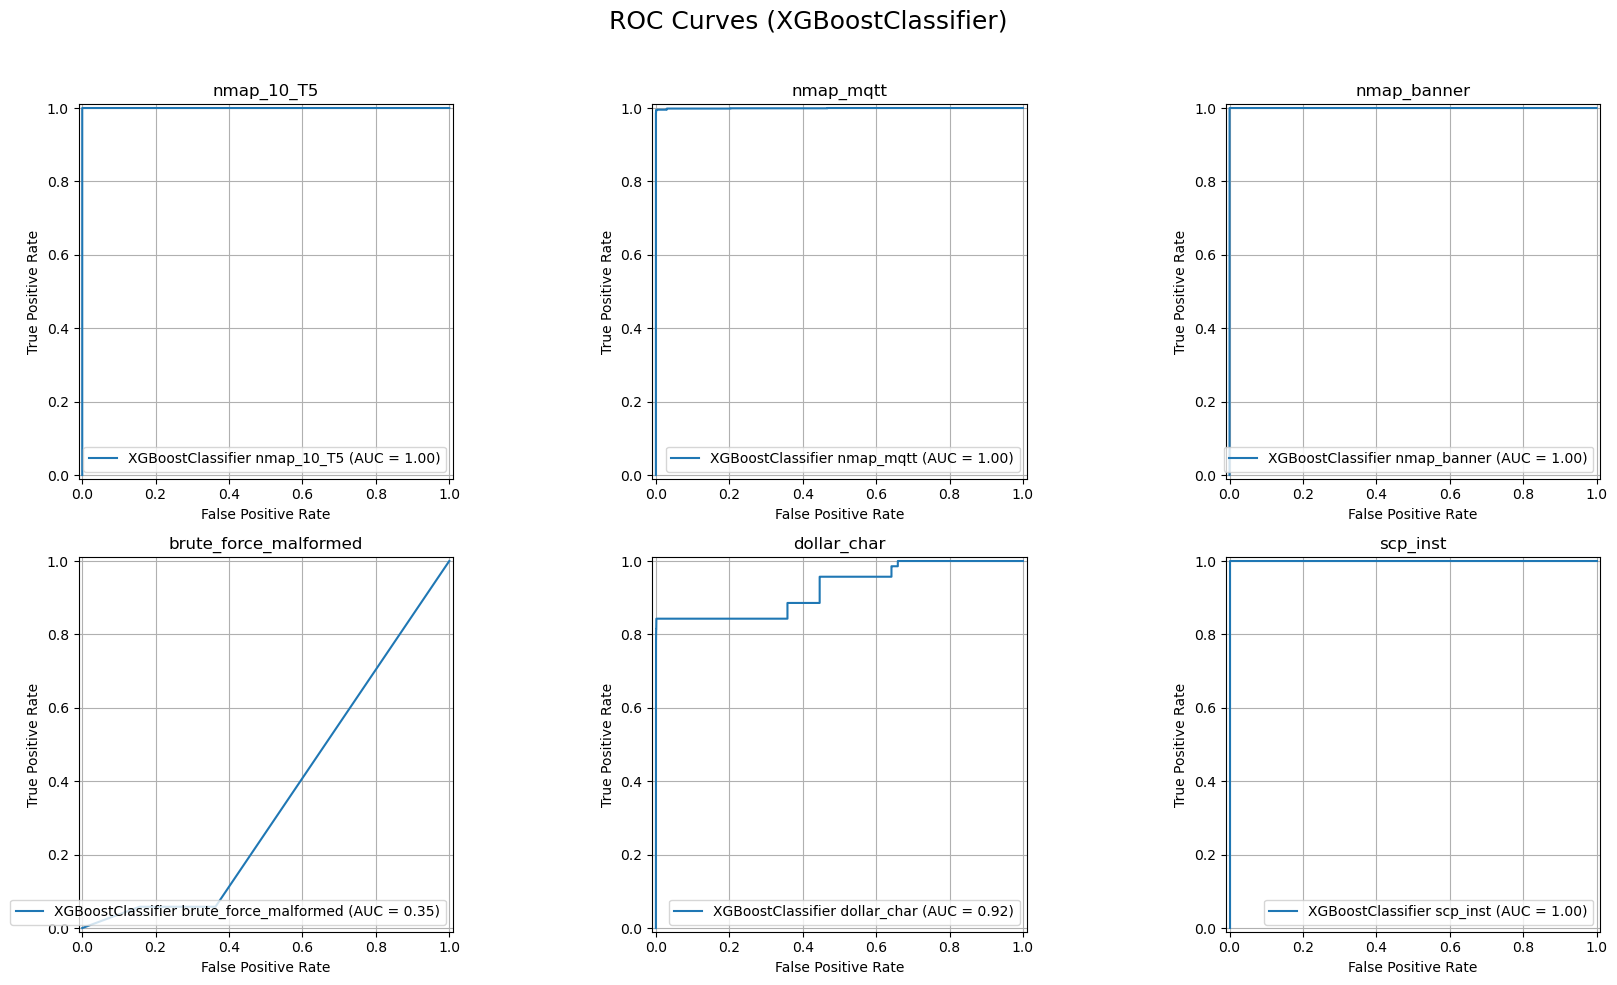

{'nmap_10_T5': array([2.3289354e-05, 1.2304169e-05, 1.6111946e-05, ..., 5.4263883e-06,
        5.4263883e-06, 5.4263883e-06], shape=(296131,), dtype=float32),
 'nmap_mqtt': array([1.2325524e-08, 1.2553813e-06, 1.9005856e-08, ..., 1.4972512e-08,
        1.9595574e-10, 2.4245634e-05], shape=(296131,), dtype=float32),
 'nmap_banner': array([5.4434843e-02, 5.6731938e-03, 2.5574643e-02, ..., 4.1148072e-09,
        4.1148072e-09, 4.1148072e-09], shape=(296131,), dtype=float32),
 'brute_force_malformed': array([1., 1., 1., ..., 1., 1., 1.], shape=(296131,), dtype=float32),
 'dollar_char': array([3.0066358e-39, 1.7745301e-38, 1.2711465e-27, ..., 2.8442553e-06,
        3.6832813e-27, 1.0000000e+00], shape=(296131,), dtype=float32),
 'scp_inst': array([9.8091450e-06, 1.0756505e-05, 1.0728880e-06, ..., 1.0756505e-05,
        1.0756505e-05, 1.0756505e-05], shape=(296131,), dtype=float32)}

In [93]:
show_roc_mapper(xgb_dict,"XGBoostClassifier")

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warning

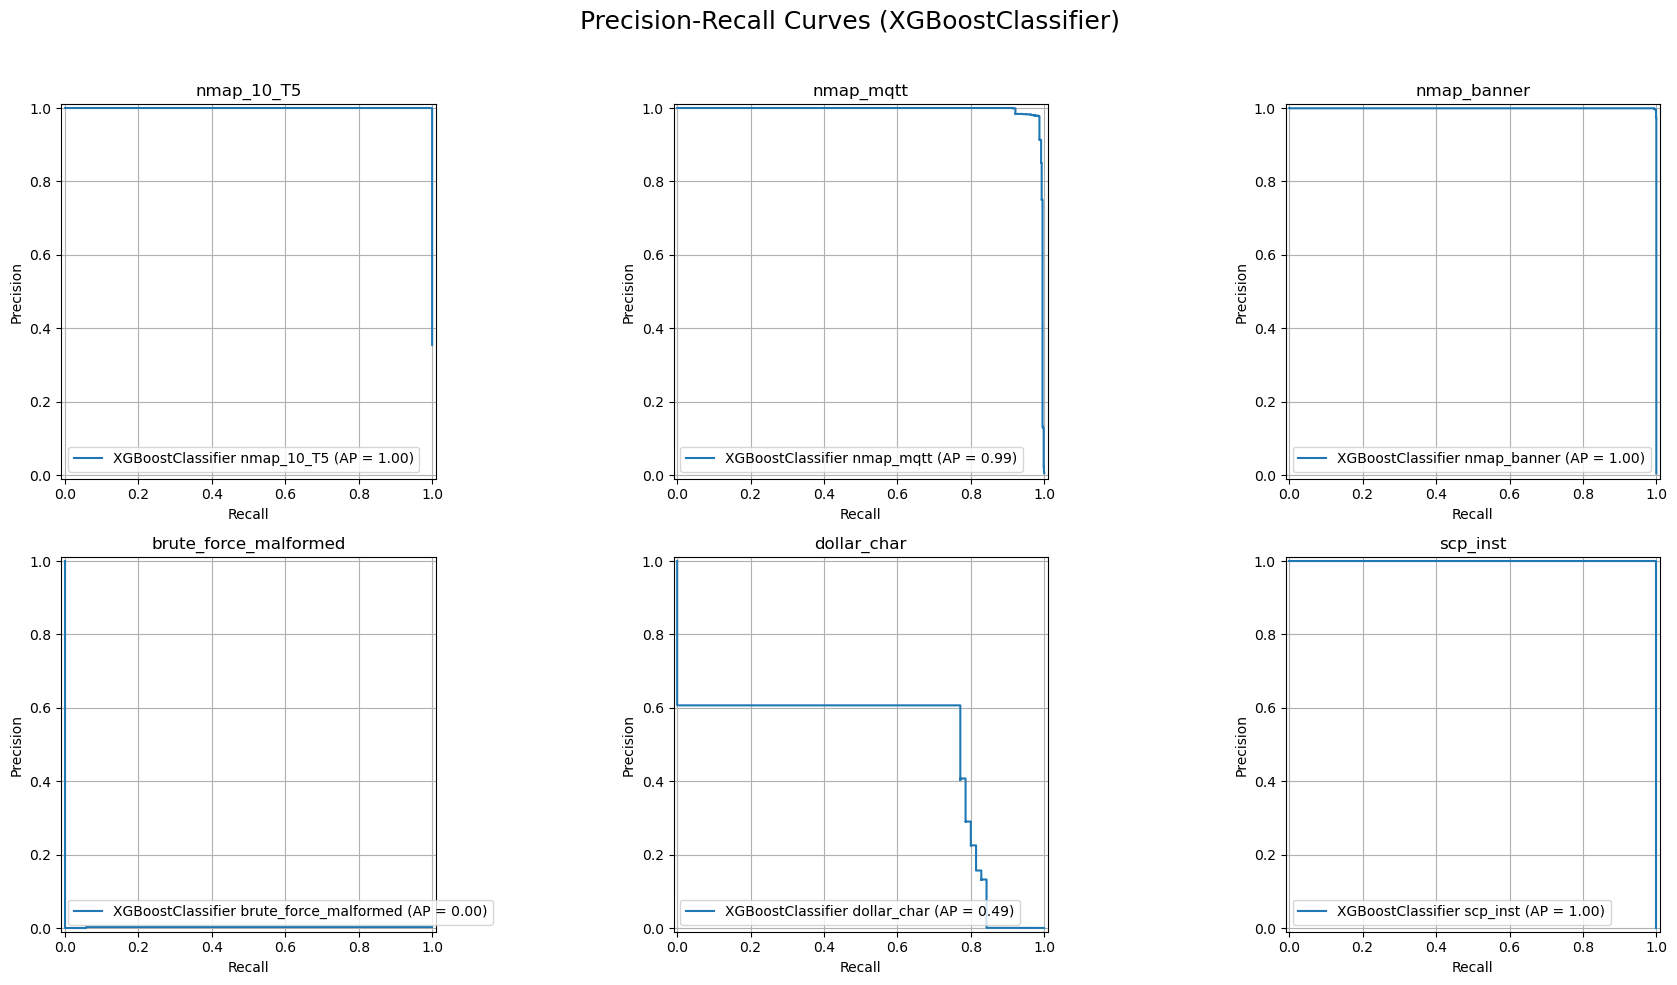

{'nmap_10_T5': array([2.3289354e-05, 1.2304169e-05, 1.6111946e-05, ..., 5.4263883e-06,
        5.4263883e-06, 5.4263883e-06], shape=(296131,), dtype=float32),
 'nmap_mqtt': array([1.2325524e-08, 1.2553813e-06, 1.9005856e-08, ..., 1.4972512e-08,
        1.9595574e-10, 2.4245634e-05], shape=(296131,), dtype=float32),
 'nmap_banner': array([5.4434843e-02, 5.6731938e-03, 2.5574643e-02, ..., 4.1148072e-09,
        4.1148072e-09, 4.1148072e-09], shape=(296131,), dtype=float32),
 'brute_force_malformed': array([1., 1., 1., ..., 1., 1., 1.], shape=(296131,), dtype=float32),
 'dollar_char': array([3.0066358e-39, 1.7745301e-38, 1.2711465e-27, ..., 2.8442553e-06,
        3.6832813e-27, 1.0000000e+00], shape=(296131,), dtype=float32),
 'scp_inst': array([9.8091450e-06, 1.0756505e-05, 1.0728880e-06, ..., 1.0756505e-05,
        1.0756505e-05, 1.0756505e-05], shape=(296131,), dtype=float32)}

In [94]:
show_prc_mapper(xgb_dict,"XGBoostClassifier")

In [95]:
evaluate_mapper(naive_bayes_dict,"GaussianNB")

GaussianNB test accuracy for nmap_10_T5: 0.996
GaussianNB test recall for nmap_10_T5: 0.999
GaussianNB test precision for nmap_10_T5: 0.989
GaussianNB test accuracy for nmap_mqtt: 0.665
GaussianNB test recall for nmap_mqtt: 0.982
GaussianNB test precision for nmap_mqtt: 0.013
GaussianNB test accuracy for nmap_banner: 0.655
GaussianNB test recall for nmap_banner: 0.966
GaussianNB test precision for nmap_banner: 0.012
GaussianNB test accuracy for brute_force_malformed: 1.000
GaussianNB test recall for brute_force_malformed: 0.998
GaussianNB test precision for brute_force_malformed: 0.980
GaussianNB test accuracy for dollar_char: 0.914
GaussianNB test recall for dollar_char: 0.957
GaussianNB test precision for dollar_char: 0.003
GaussianNB test accuracy for scp_inst: 1.000
GaussianNB test recall for scp_inst: 1.000
GaussianNB test precision for scp_inst: 1.000


/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.wa

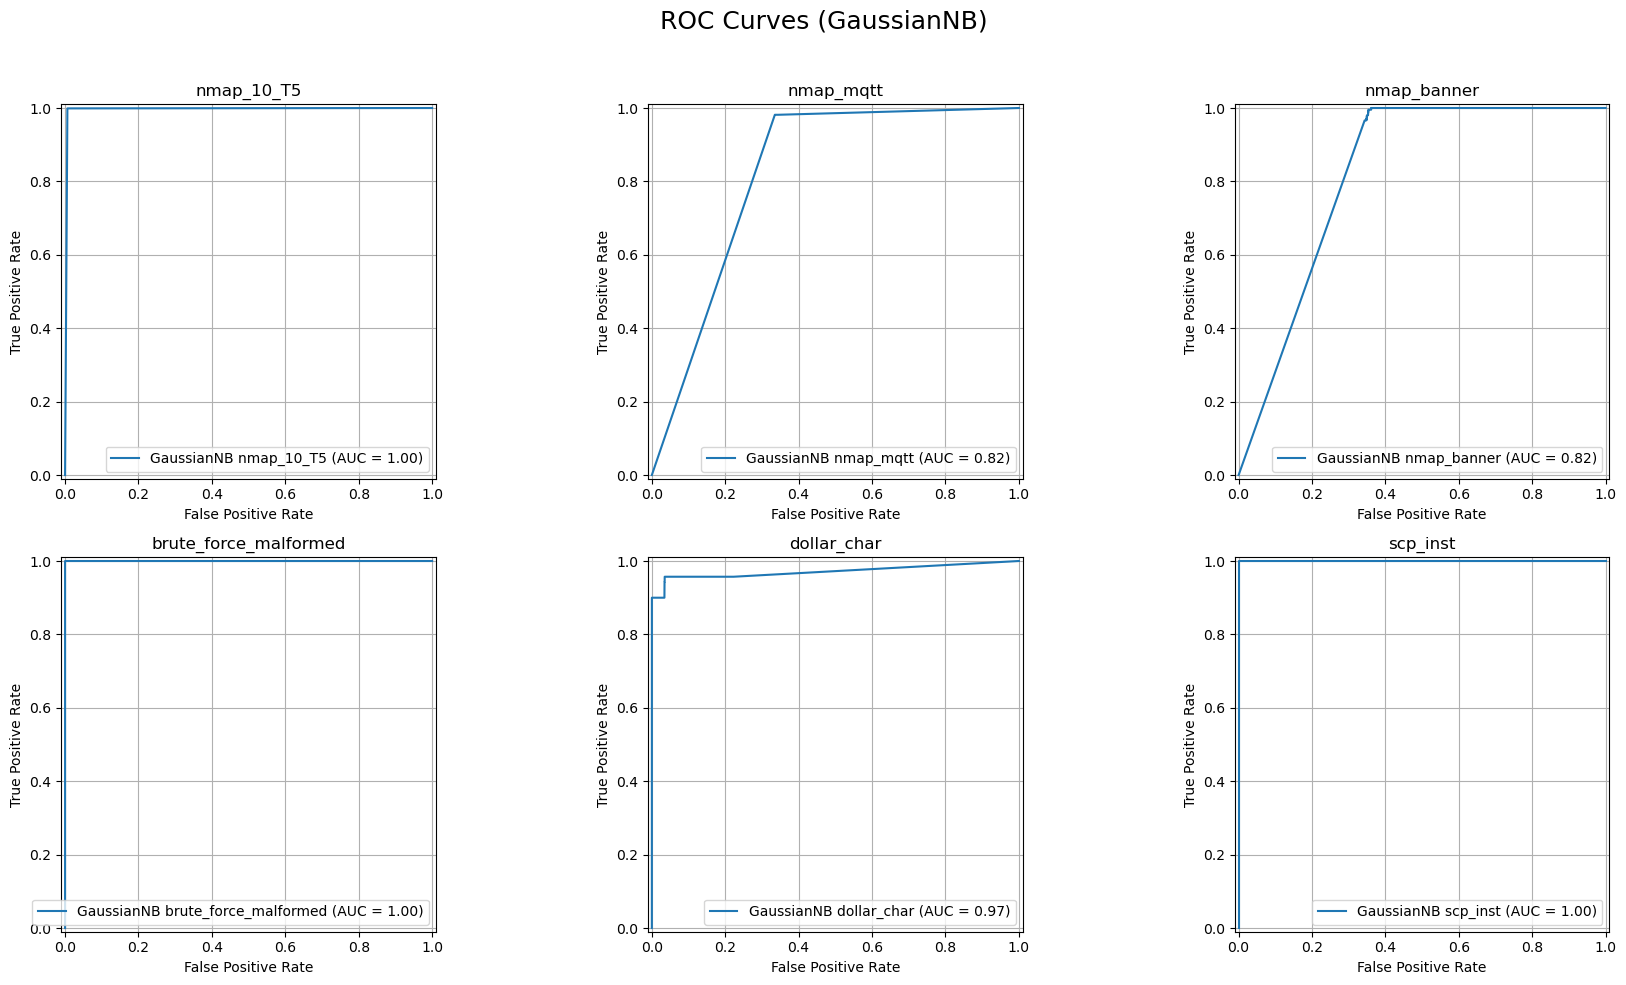

{'nmap_10_T5': array([0., 0., 0., ..., 0., 0., 0.], shape=(296131,)),
 'nmap_mqtt': array([0., 0., 0., ..., 0., 0., 0.], shape=(296131,)),
 'nmap_banner': array([1.27038350e-06, 4.90969446e-05, 1.07407524e-04, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00], shape=(296131,)),
 'brute_force_malformed': array([0., 0., 0., ..., 0., 0., 0.], shape=(296131,)),
 'dollar_char': array([0., 0., 0., ..., 1., 1., 1.], shape=(296131,)),
 'scp_inst': array([0., 0., 0., ..., 0., 0., 0.], shape=(296131,))}

In [96]:
show_roc_mapper(naive_bayes_dict,"GaussianNB")

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warning

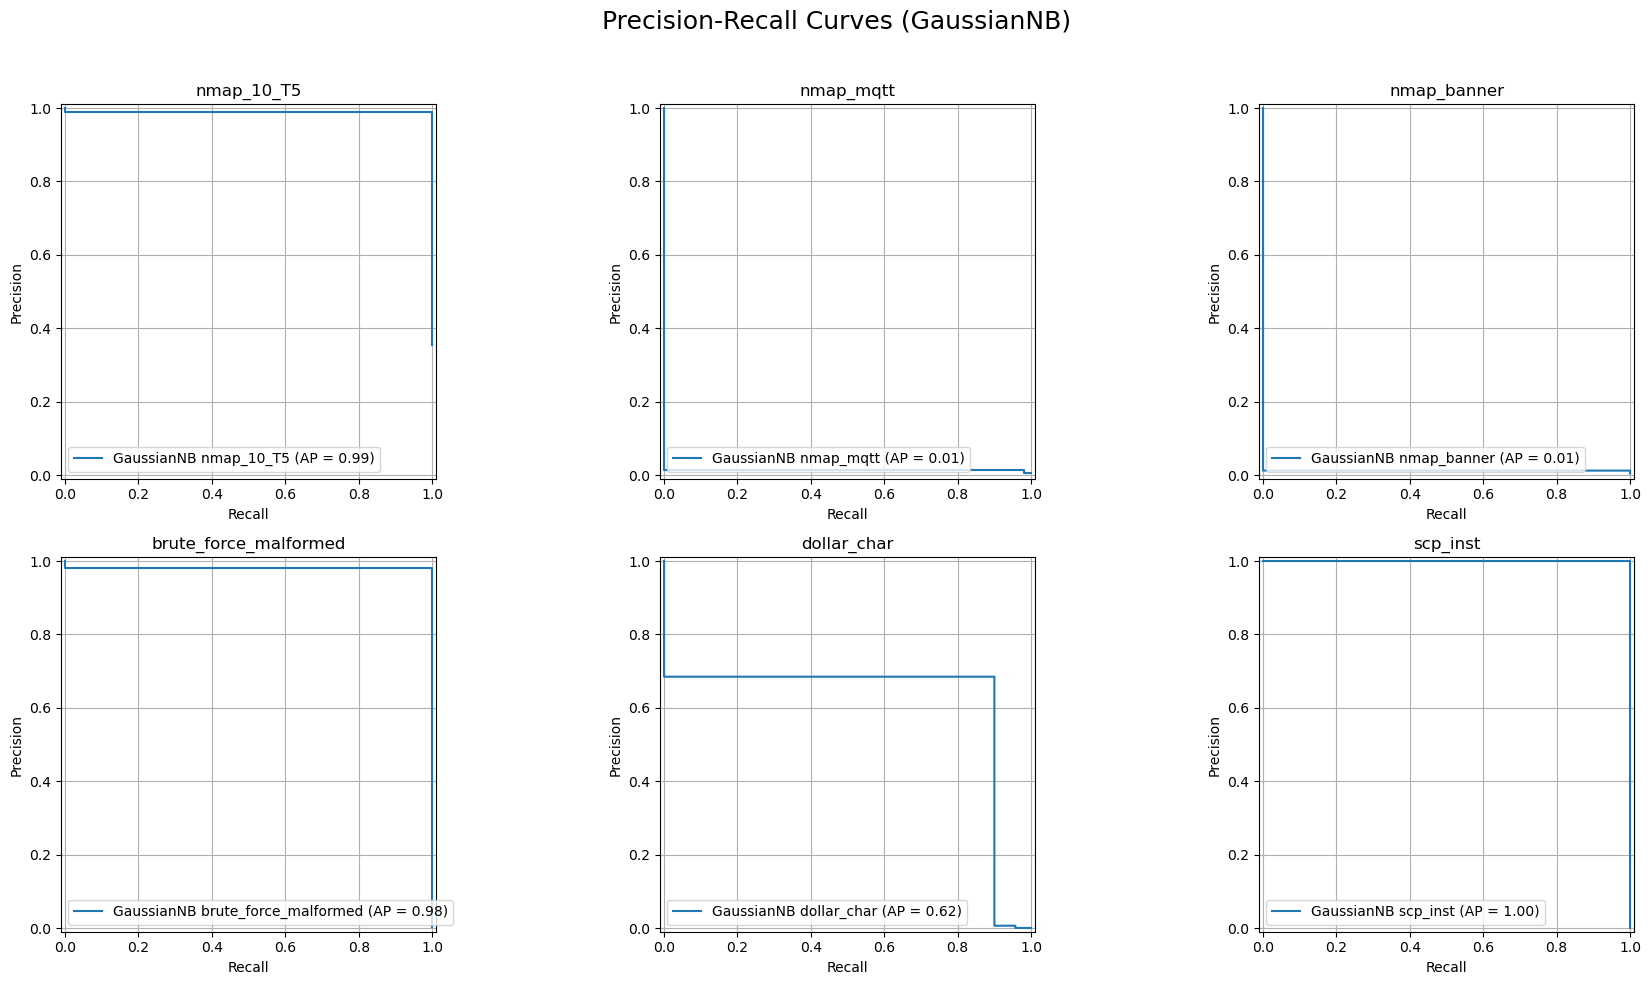

{'nmap_10_T5': array([0., 0., 0., ..., 0., 0., 0.], shape=(296131,)),
 'nmap_mqtt': array([0., 0., 0., ..., 0., 0., 0.], shape=(296131,)),
 'nmap_banner': array([1.27038350e-06, 4.90969446e-05, 1.07407524e-04, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00], shape=(296131,)),
 'brute_force_malformed': array([0., 0., 0., ..., 0., 0., 0.], shape=(296131,)),
 'dollar_char': array([0., 0., 0., ..., 1., 1., 1.], shape=(296131,)),
 'scp_inst': array([0., 0., 0., ..., 0., 0., 0.], shape=(296131,))}

In [97]:
show_prc_mapper(naive_bayes_dict,"GaussianNB")

In [98]:
evaluate_mapper(qda_dict,"QuadraticDiscriminantAnalysis")

QuadraticDiscriminantAnalysis test accuracy for nmap_10_T5: 0.976
QuadraticDiscriminantAnalysis test recall for nmap_10_T5: 0.951
QuadraticDiscriminantAnalysis test precision for nmap_10_T5: 0.981
QuadraticDiscriminantAnalysis test accuracy for nmap_mqtt: 0.706
QuadraticDiscriminantAnalysis test recall for nmap_mqtt: 0.976
QuadraticDiscriminantAnalysis test precision for nmap_mqtt: 0.014
QuadraticDiscriminantAnalysis test accuracy for nmap_banner: 0.986
QuadraticDiscriminantAnalysis test recall for nmap_banner: 0.969
QuadraticDiscriminantAnalysis test precision for nmap_banner: 0.238
QuadraticDiscriminantAnalysis test accuracy for brute_force_malformed: 0.999
QuadraticDiscriminantAnalysis test recall for brute_force_malformed: 0.942
QuadraticDiscriminantAnalysis test precision for brute_force_malformed: 0.629
QuadraticDiscriminantAnalysis test accuracy for dollar_char: 0.969
QuadraticDiscriminantAnalysis test recall for dollar_char: 0.943
QuadraticDiscriminantAnalysis test precision fo

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.wa

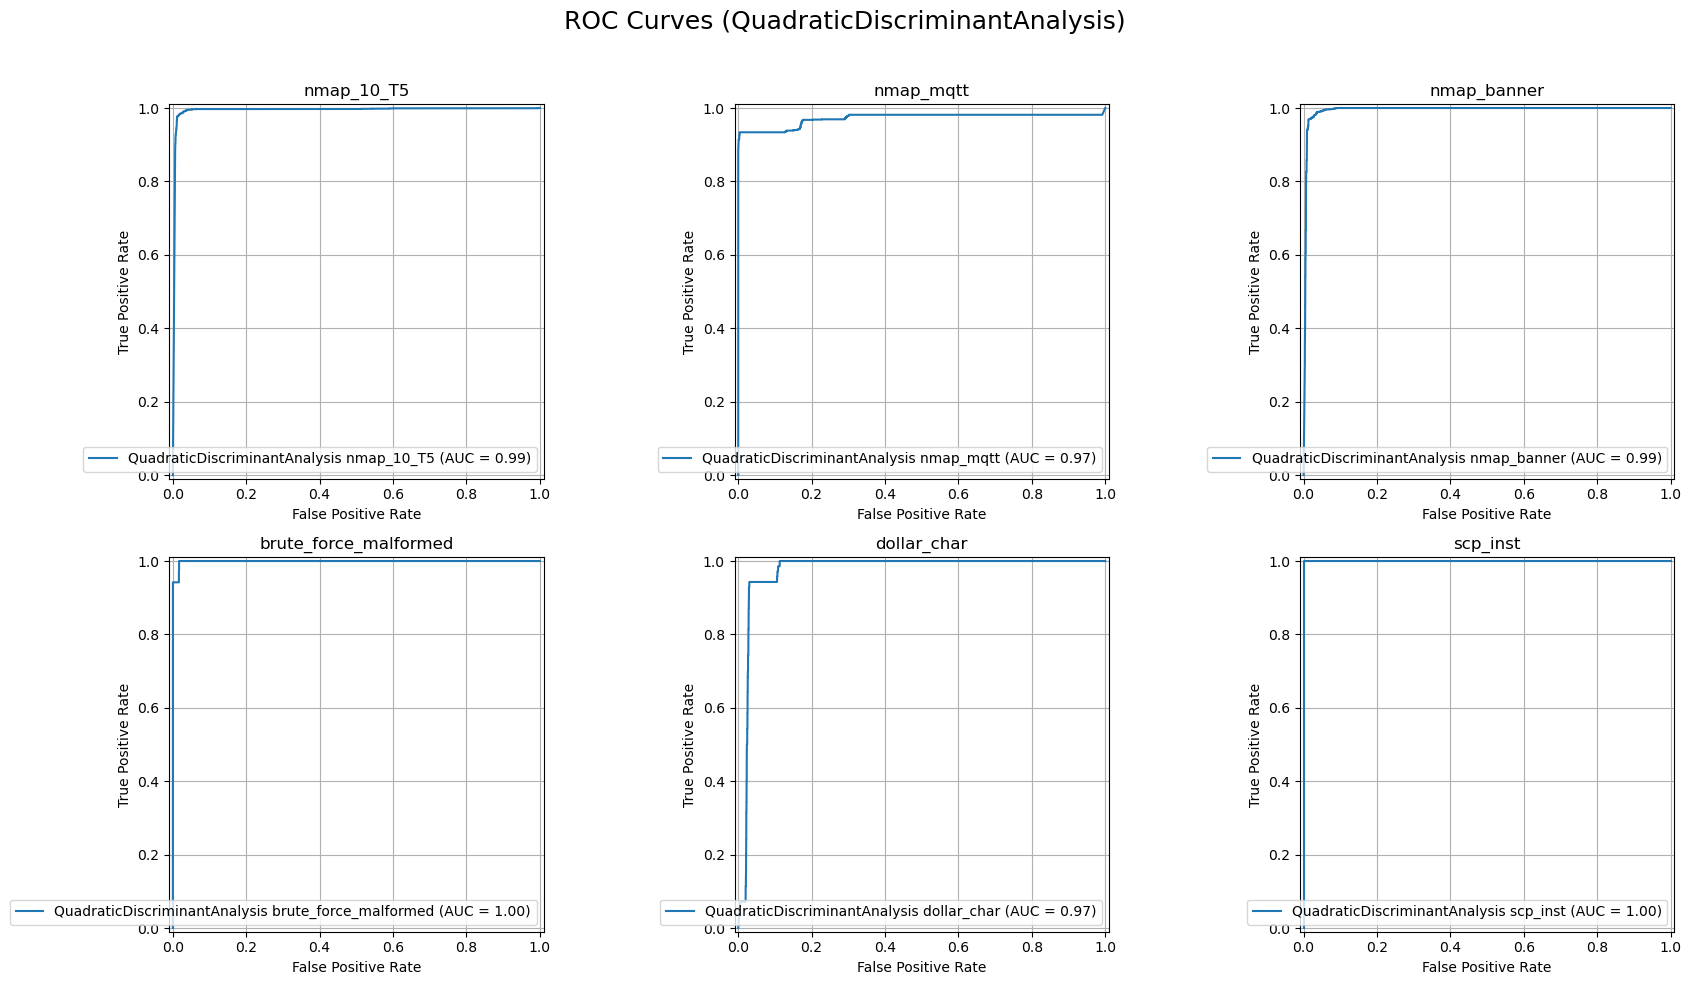

{'nmap_10_T5': array([9.99998033e-01, 9.99398064e-01, 9.99999961e-01, ...,
        6.17503956e-15, 1.50090696e-14, 2.34180795e-08], shape=(296131,)),
 'nmap_mqtt': array([9.90408925e-01, 6.98521848e-01, 9.99982070e-01, ...,
        3.21037358e-27, 8.88736717e-27, 1.12291932e-19], shape=(296131,)),
 'nmap_banner': array([3.33880611e-07, 1.13835720e-07, 3.41903335e-09, ...,
        3.07715154e-10, 1.57945673e-09, 5.97298852e-10], shape=(296131,)),
 'brute_force_malformed': array([4.96526903e-89, 2.66872878e-89, 9.21533640e-90, ...,
        1.35943080e-94, 2.68952106e-94, 1.76975840e-93], shape=(296131,)),
 'dollar_char': array([0.96855195, 0.92322082, 0.86779668, ..., 0.99925602, 0.99891089,
        0.99557905], shape=(296131,)),
 'scp_inst': array([0., 0., 0., ..., 0., 0., 0.], shape=(296131,))}

In [99]:
show_roc_mapper(qda_dict,"QuadraticDiscriminantAnalysis")

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warning

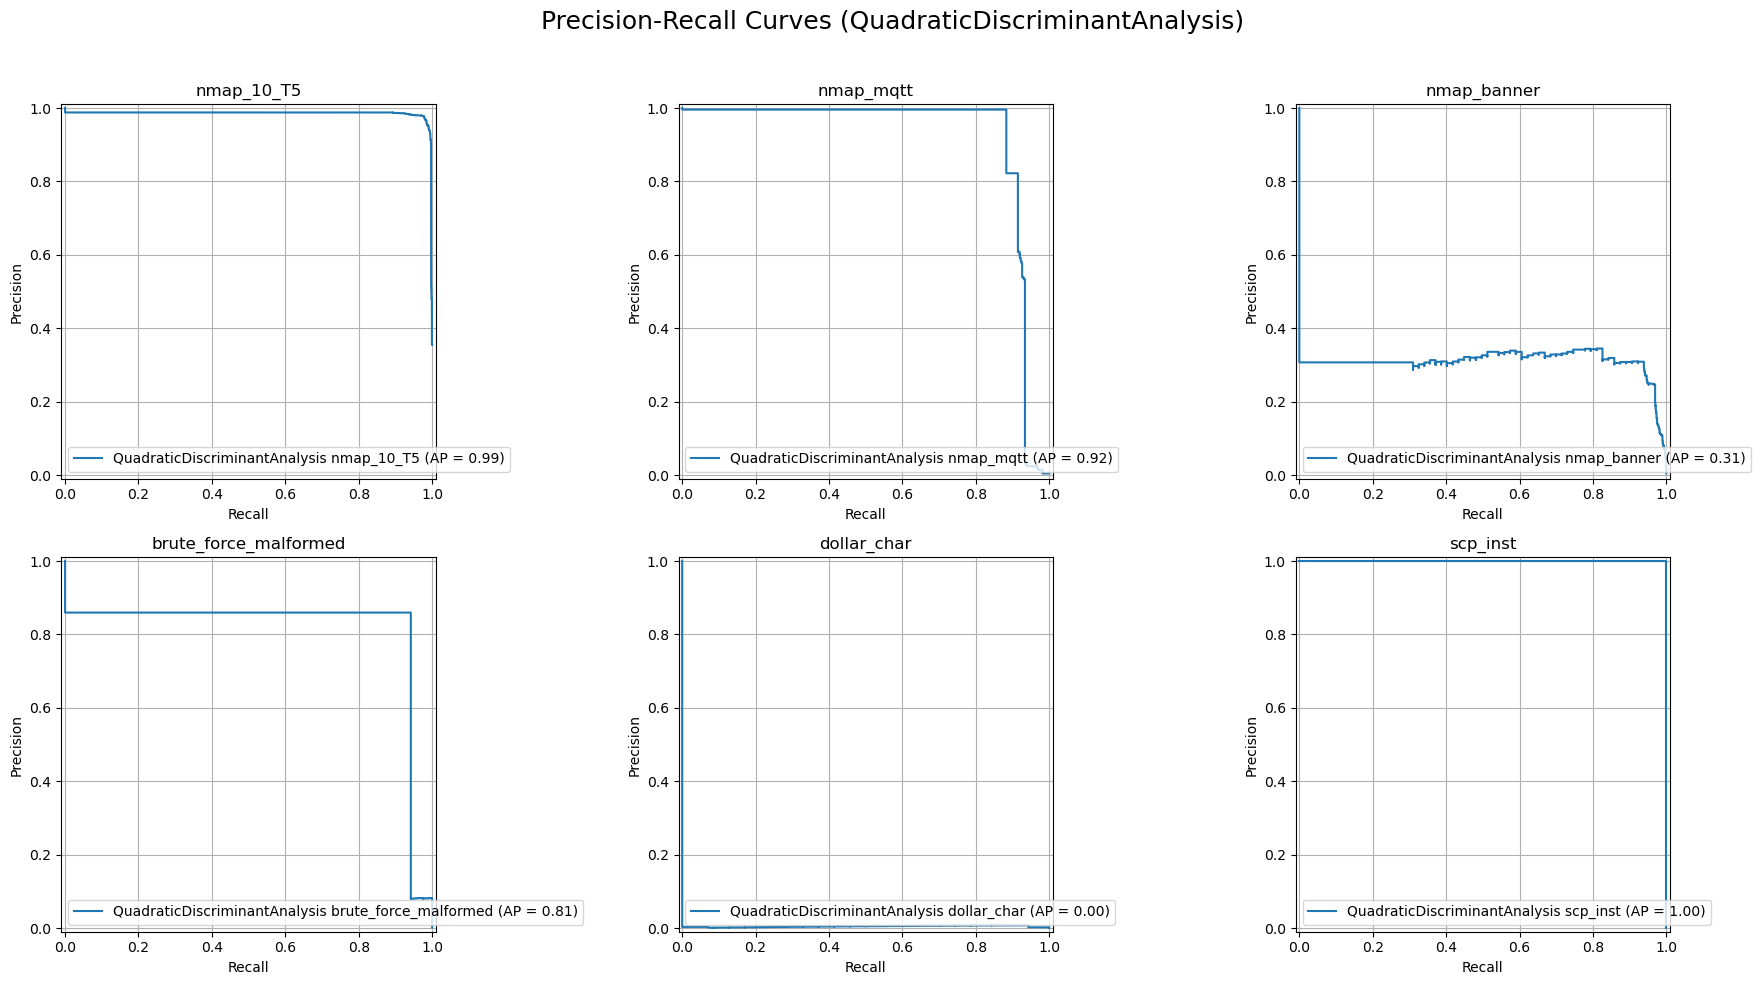

{'nmap_10_T5': array([9.99998033e-01, 9.99398064e-01, 9.99999961e-01, ...,
        6.17503956e-15, 1.50090696e-14, 2.34180795e-08], shape=(296131,)),
 'nmap_mqtt': array([9.90408925e-01, 6.98521848e-01, 9.99982070e-01, ...,
        3.21037358e-27, 8.88736717e-27, 1.12291932e-19], shape=(296131,)),
 'nmap_banner': array([3.33880611e-07, 1.13835720e-07, 3.41903335e-09, ...,
        3.07715154e-10, 1.57945673e-09, 5.97298852e-10], shape=(296131,)),
 'brute_force_malformed': array([4.96526903e-89, 2.66872878e-89, 9.21533640e-90, ...,
        1.35943080e-94, 2.68952106e-94, 1.76975840e-93], shape=(296131,)),
 'dollar_char': array([0.96855195, 0.92322082, 0.86779668, ..., 0.99925602, 0.99891089,
        0.99557905], shape=(296131,)),
 'scp_inst': array([0., 0., 0., ..., 0., 0., 0.], shape=(296131,))}

In [100]:
show_prc_mapper(qda_dict,"QuadraticDiscriminantAnalysis")

In [101]:
evaluate_mapper(logistic_regression_dict,"LogisticRegression")

LogisticRegression test accuracy for nmap_10_T5: 1.000
LogisticRegression test recall for nmap_10_T5: 1.000
LogisticRegression test precision for nmap_10_T5: 0.999
LogisticRegression test accuracy for nmap_mqtt: 1.000
LogisticRegression test recall for nmap_mqtt: 0.928
LogisticRegression test precision for nmap_mqtt: 0.993
LogisticRegression test accuracy for nmap_banner: 1.000
LogisticRegression test recall for nmap_banner: 0.968
LogisticRegression test precision for nmap_banner: 1.000
LogisticRegression test accuracy for brute_force_malformed: 1.000
LogisticRegression test recall for brute_force_malformed: 0.980
LogisticRegression test precision for brute_force_malformed: 0.989
LogisticRegression test accuracy for dollar_char: 1.000
LogisticRegression test recall for dollar_char: 0.829
LogisticRegression test precision for dollar_char: 1.000
LogisticRegression test accuracy for scp_inst: 1.000
LogisticRegression test recall for scp_inst: 0.000
LogisticRegression test precision for sc

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.wa

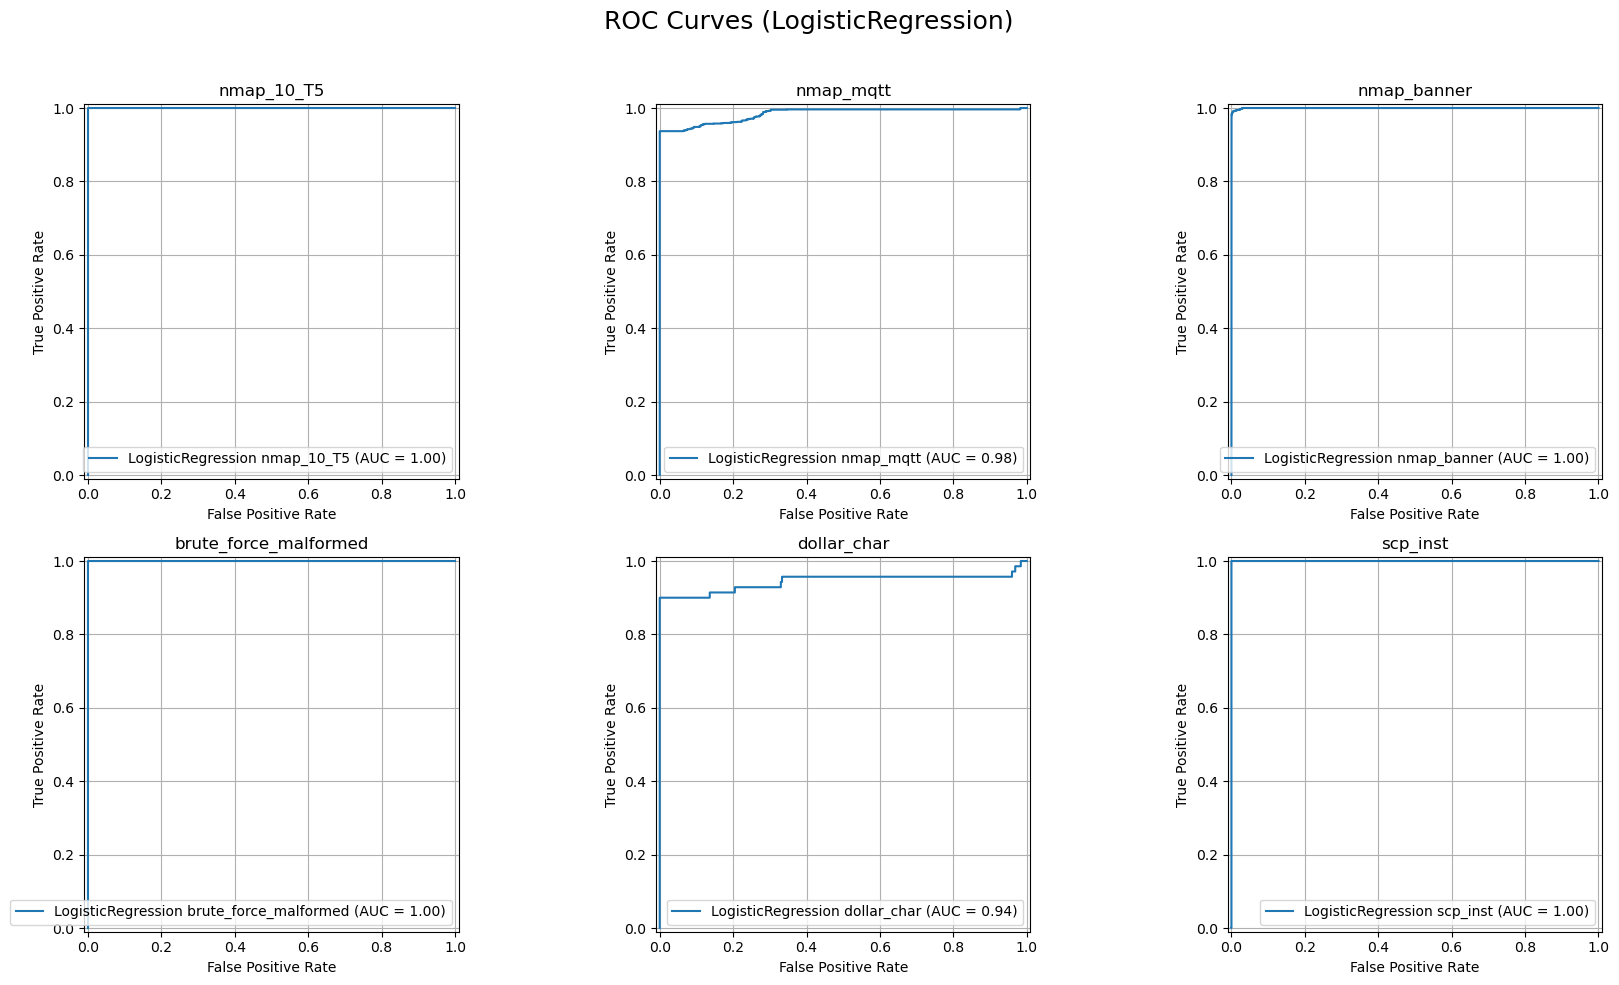

{'nmap_10_T5': array([8.40824275e-06, 2.70459197e-06, 4.25638833e-06, ...,
        1.23236845e-08, 1.10561943e-08, 1.74308235e-08], shape=(296131,)),
 'nmap_mqtt': array([0.1909803 , 0.29062715, 0.38743568, ..., 0.00067648, 0.00072345,
        0.00117786], shape=(296131,)),
 'nmap_banner': array([0.04424854, 0.33553907, 0.07642118, ..., 0.03342889, 0.07054597,
        0.04918728], shape=(296131,)),
 'brute_force_malformed': array([0.08776717, 0.06907104, 0.12066095, ..., 0.01094444, 0.01063772,
        0.01703734], shape=(296131,)),
 'dollar_char': array([0.08972395, 0.0879762 , 0.11480613, ..., 0.88948676, 0.84078117,
        0.77270227], shape=(296131,)),
 'scp_inst': array([2.49683288e-05, 2.56166241e-05, 2.67170946e-05, ...,
        2.73146692e-05, 2.75162013e-05, 2.78055976e-05], shape=(296131,))}

In [102]:
show_roc_mapper(logistic_regression_dict,"LogisticRegression")

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warning

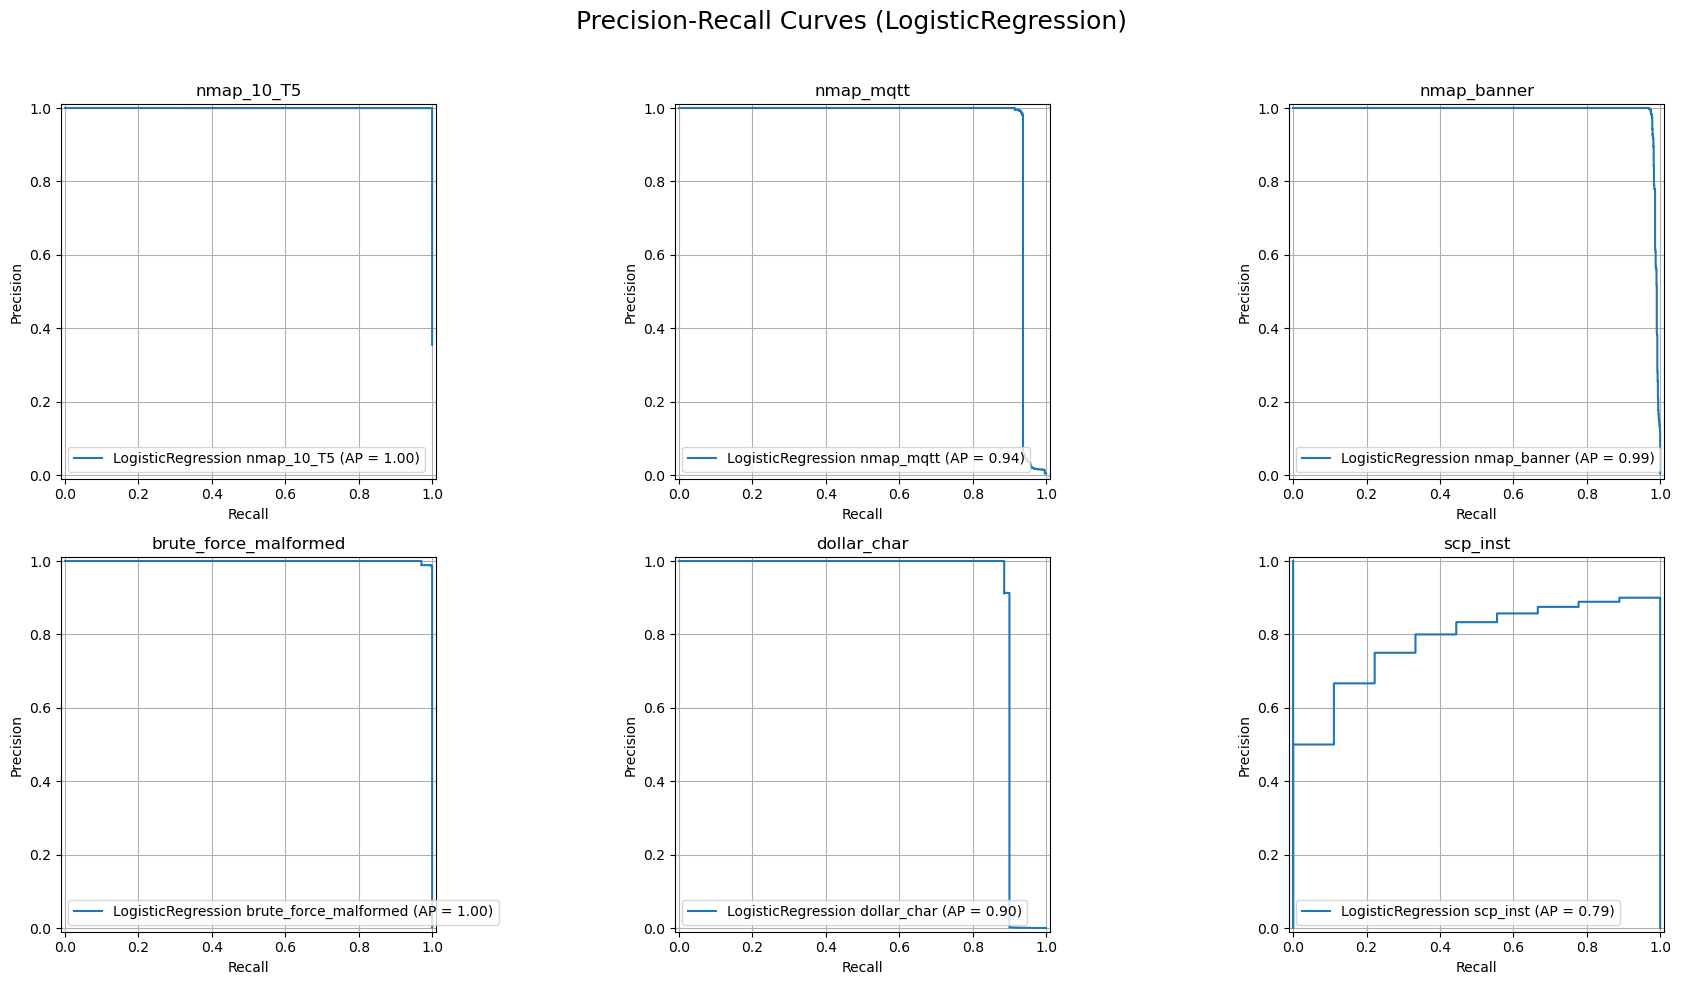

{'nmap_10_T5': array([8.40824275e-06, 2.70459197e-06, 4.25638833e-06, ...,
        1.23236845e-08, 1.10561943e-08, 1.74308235e-08], shape=(296131,)),
 'nmap_mqtt': array([0.1909803 , 0.29062715, 0.38743568, ..., 0.00067648, 0.00072345,
        0.00117786], shape=(296131,)),
 'nmap_banner': array([0.04424854, 0.33553907, 0.07642118, ..., 0.03342889, 0.07054597,
        0.04918728], shape=(296131,)),
 'brute_force_malformed': array([0.08776717, 0.06907104, 0.12066095, ..., 0.01094444, 0.01063772,
        0.01703734], shape=(296131,)),
 'dollar_char': array([0.08972395, 0.0879762 , 0.11480613, ..., 0.88948676, 0.84078117,
        0.77270227], shape=(296131,)),
 'scp_inst': array([2.49683288e-05, 2.56166241e-05, 2.67170946e-05, ...,
        2.73146692e-05, 2.75162013e-05, 2.78055976e-05], shape=(296131,))}

In [103]:
show_prc_mapper(logistic_regression_dict,"LogisticRegression")

### 1.3.10 - Computing attack type score

In [104]:
xgb_attack_type_prob={}

In [105]:
# choose the attack type mapper you want to use
for label, xgboost in xgb_dict.items():
    y_prob = xgboost.predict_proba(X_test_dict[label])[:, 1]
    xgb_attack_type_prob[label]=y_prob

In [106]:
for key, prob_vector in xgb_attack_type_prob.items():
    print(key+f":{prob_vector.shape[0]}")

nmap_10_T5:296131
nmap_mqtt:296131
nmap_banner:296131
brute_force_malformed:296131
dollar_char:296131
scp_inst:296131


In [107]:
gnb_attack_type_prob={}

In [108]:
# choose the attack type mapper you want to use
for label, gaussiannb in naive_bayes_dict.items():
    y_prob = gaussiannb.predict_proba(X_test_dict[label])[:, 1]
    gnb_attack_type_prob[label]=y_prob

In [109]:
for key, prob_vector in gnb_attack_type_prob.items():
    print(key+f":{prob_vector.shape[0]}")

nmap_10_T5:296131
nmap_mqtt:296131
nmap_banner:296131
brute_force_malformed:296131
dollar_char:296131
scp_inst:296131


In [110]:
perfect_type_prob={}

In [111]:
# choose the attack type mapper you want to use
for label, score in y_test_dict.items():
    perfect_type_prob[label] = score

In [112]:
for key, prob_vector in perfect_type_prob.items():
    print(key+f":{prob_vector.shape[0]}")

nmap_10_T5:296131
nmap_mqtt:296131
nmap_banner:296131
brute_force_malformed:296131
dollar_char:296131
scp_inst:296131


## 1.4 - Building the scenario reconstruction dataset

### 1.4.1 - Loading the starting dataset 

In [113]:
import numpy as np
import pandas as pd
df_rec=pd.read_csv("data/test.csv")
df_rec["index"] = pd.Series(np.arange(len(df_rec)))
df_rec.info()

/tmp/ipykernel_3082752/2153923168.py:3: DtypeWarning: Columns (0: client_fingerprint, 1: server_fingerprint) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rec=pd.read_csv("data/test.csv")


<class 'pandas.DataFrame'>
RangeIndex: 296132 entries, 0 to 296131
Data columns (total 90 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   id                            296132 non-null  int64  
 1   expiration_id                 296132 non-null  int64  
 2   src_ip                        296132 non-null  str    
 3   src_mac                       296132 non-null  str    
 4   src_oui                       296132 non-null  str    
 5   src_port                      296132 non-null  int64  
 6   dst_ip                        296132 non-null  str    
 7   dst_mac                       296132 non-null  str    
 8   dst_oui                       296132 non-null  str    
 9   dst_port                      296132 non-null  int64  
 10  protocol                      121482 non-null  float64
 11  ip_version                    296132 non-null  int64  
 12  vlan_id                       296132 non-null  int64  


In [114]:
import numpy as np
df_rec = df_rec.dropna(thresh=2, axis=0)
df_rec = df_rec.dropna(thresh=2, axis=0)

In [115]:
df_rec=df_rec[df_rec["label"].isin(df_train["label"].unique())]
df_rec=df_rec[df_rec["label"].isin(df_test["label"].unique())]

In [116]:
attack_steps = (
    df_rec
    .groupby('label', as_index=False)
    .agg(total_steps=('step_number', 'nunique'))
)

print(attack_steps)

                   label  total_steps
0  brute_force_malformed            1
1            dollar_char           63
2             nmap_10_T5            5
3            nmap_banner           20
4              nmap_mqtt           29
5                 normal            1
6               scp_inst            9


In [117]:
print(df_rec.shape[0])

296131


### 1.4.2 - Further step subdivision

In [118]:
attack = df_rec["step_number"] != -1
groups = (
    df_rec.loc[attack]
      .groupby(["step_number", "src_ip", "dst_ip"], sort=False)
      .ngroup()
)
df_rec.loc[attack, "step_number"] = groups

In [119]:
attack_steps = (
    df_rec[df_rec["label"]!="normal"]
    .groupby('label', as_index=False)
    .agg(total_steps=('step_number', 'nunique'))
)

In [120]:
attack_steps

,label,total_steps
0,brute_force_malformed,1
1,dollar_char,68
2,nmap_10_T5,105
3,nmap_banner,844
4,nmap_mqtt,662
5,scp_inst,9


In [121]:
df = df_rec.sort_values('timestamp').reset_index(drop=True)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df=df[df["label"]!="normal"]

step_summary = (
    df.groupby('step_number', as_index=False)
      .agg(
          label        = ('label', 'first'),
          num_flws     = ('timestamp', 'size'),
          start_time   = ('timestamp', 'min'),
          end_time     = ('timestamp', 'max')
      )
      .assign(duration=lambda g: g['end_time'] - g['start_time'])
)

step_summary['fps'] = (
    step_summary['num_flws'] /
    step_summary['duration'].dt.total_seconds().replace(0, np.nan)
)

label_summary = (
    step_summary.groupby('label', as_index=False)
               .agg(
                   avg_num_flws    = ('num_flws', 'mean'),
                   median_num_flws = ('num_flws', 'median'),
                   avg_duration    = ('duration', 'mean'),
                   median_duration = ('duration', 'median'),
                   total_steps = ('step_number', 'nunique'),
                   total_flws      = ('num_flws', 'sum'),
                   avg_fps         = ('fps', 'mean')
               )
)

In [122]:
step_summary

,step_number,label,num_flws,start_time,end_time,duration,fps
0,0,nmap_10_T5,1000,2025-08-20 11:44:16.352608+00:00,2025-08-20 11:44:19.393608+00:00,0 days 00:00:03.041000,328.839198
1,1,nmap_10_T5,1000,2025-08-20 11:44:16.352608+00:00,2025-08-20 11:44:19.393608+00:00,0 days 00:00:03.041000,328.839198
2,2,nmap_10_T5,1000,2025-08-20 11:44:16.353608+00:00,2025-08-20 11:44:19.387608+00:00,0 days 00:00:03.034000,329.597891
3,3,nmap_10_T5,1000,2025-08-20 11:44:16.353608+00:00,2025-08-20 11:44:19.387608+00:00,0 days 00:00:03.034000,329.597891
4,4,nmap_10_T5,1000,2025-08-20 11:44:16.353608+00:00,2025-08-20 11:44:19.394608+00:00,0 days 00:00:03.041000,328.839198
...,...,...,...,...,...,...,...
1684,1684,nmap_banner,1,2025-08-20 21:22:44.024608+00:00,2025-08-20 21:22:44.024608+00:00,0 days 00:00:00,NaN
1685,1685,nmap_banner,2,2025-08-20 21:22:44.026608+00:00,2025-08-20 21:22:44.026608+00:00,0 days 00:00:00,NaN
1686,1686,dollar_char,1,2025-08-20 21:27:19.169608+00:00,2025-08-20 21:27:19.169608+00:00,0 days 00:00:00,NaN
1687,1687,dollar_char,1,2025-08-20 21:30:47.474608+00:00,2025-08-20 21:30:47.474608+00:00,0 days 00:00:00,NaN


In [123]:
label_summary

,label,avg_num_flws,median_num_flws,avg_duration,median_duration,total_steps,total_flws,avg_fps
0,brute_force_malformed,448.000000,448.0,0 days 00:13:26.954000,0 days 00:13:26.954000,1,448,0.555174
1,dollar_char,1.029412,1.0,0 days 00:00:03.534250,0 days 00:00:00,68,70,0.016644
2,nmap_10_T5,1000.000000,1000.0,0 days 00:00:03.252104,0 days 00:00:03.357000,105,105000,308.751201
3,nmap_banner,1.545024,2.0,0 days 00:00:00.244703,0 days 00:00:00.002500,844,1304,202.052549
4,nmap_mqtt,1.963746,2.0,0 days 00:00:05.632996,0 days 00:00:00.401000,662,1300,4.760404
5,scp_inst,1.000000,1.0,0 days 00:00:00,0 days 00:00:00,9,9,NaN


### 1.4.3 - Extracting reconstruction features

In [124]:
rec_cols=["src_ip", "src_port", "dst_ip", "dst_port", "protocol", "timestamp", "bidirectional_duration_ms", "label", "step_number", "index"]
df_rec=df_rec[rec_cols]
df_rec["duration"]=df_rec["bidirectional_duration_ms"]
df_rec=df_rec.drop("bidirectional_duration_ms", axis=1)

In [125]:
print(df_rec.shape[0])

296131


### 1.4.4 - Adding new features

In [126]:
df_rec_dict={}
for name, col in anomaly_score_dict.items(): 
    xgb_df_rec = df_rec.copy()
    anomaly_df = pd.DataFrame({"index": ind_test, "anomaly_score": col})
    xgb_df_rec = xgb_df_rec.merge(anomaly_df, on="index", how="inner", validate="one_to_one")
    for attack_type, type_prob in xgb_attack_type_prob.items():
        type_df=pd.DataFrame({"index": ind_test, attack_type: type_prob})
        xgb_df_rec = xgb_df_rec.merge(type_df, on="index", how="inner", validate="one_to_one")
    xgb_df_rec.info()
    df_rec_dict[name+"_xgb"]=xgb_df_rec

    gnb_df_rec = df_rec.copy()
    anomaly_df = pd.DataFrame({"index": ind_test, "anomaly_score": col})
    gnb_df_rec = gnb_df_rec.merge(anomaly_df, on="index", how="inner", validate="one_to_one")
    for attack_type, type_prob in gnb_attack_type_prob.items():
        type_df=pd.DataFrame({"index": ind_test, attack_type: type_prob})
        gnb_df_rec = gnb_df_rec.merge(type_df, on="index", how="inner", validate="one_to_one")
    gnb_df_rec.info()
    df_rec_dict[name+"_gnb"]=gnb_df_rec

    perfect_df_rec=df_rec.copy()
    anomaly_df = pd.DataFrame({"index": ind_test, "anomaly_score": col})
    perfect_df_rec = perfect_df_rec.merge(anomaly_df, on="index", how="inner", validate="one_to_one")
    for attack_type, type_prob in perfect_type_prob.items():
        type_df=pd.DataFrame({"index": ind_test, attack_type: type_prob})
        perfect_df_rec = perfect_df_rec.merge(type_df, on="index", how="inner", validate="one_to_one")
    perfect_df_rec.info()
    df_rec_dict[name+"_perfect"]=perfect_df_rec

<class 'pandas.DataFrame'>
RangeIndex: 296131 entries, 0 to 296130
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   src_ip                 296131 non-null  str    
 1   src_port               296131 non-null  int64  
 2   dst_ip                 296131 non-null  str    
 3   dst_port               296131 non-null  int64  
 4   protocol               121481 non-null  float64
 5   timestamp              296131 non-null  str    
 6   label                  296131 non-null  str    
 7   step_number            296131 non-null  int64  
 8   index                  296131 non-null  int64  
 9   duration               296131 non-null  int64  
 10  anomaly_score          296131 non-null  float64
 11  nmap_10_T5             296131 non-null  float32
 12  nmap_mqtt              296131 non-null  float32
 13  nmap_banner            296131 non-null  float32
 14  brute_force_malformed  296131 non-null  float32

### 1.4.5 - Saving the dataset 

In [127]:
import pandas as pd
for name, df in df_rec_dict.items():
    df=df.sort_values(by="timestamp")
    df.to_csv(f"data/final datasets/{name}_rec_dataset.csv",index=False)